In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt
/kaggle/input/photos/WIN_20260117_00_03_17_Pro.jpg
/kaggle/input/video1/WhatsApp Video 2026-01-17 at 2.01.11 AM.mp4
/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg
/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/README.dataset.txt
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/README.roboflow.txt
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/construction-3-_mp4-219_jpg.rf.416dbf917b54d5895e2430fa0d6f1b66.txt
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/construction-1-_mp4-147_jpg.rf.a9062a80b06ac796f7afb269e5f18c53.txt
/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/valid/labels/Movie-on-10-31-22-at-10_08-AM_mov-13_jpg.rf.91dc3b79da617fb2e4321f27f48f21f4.txt
/kaggle/input/construction-site-safety-image-dataset-r

In [3]:
# Install DeepFace for face recognition
!pip install deepface

# Alternative options (uncomment if needed):
# !pip install insightface onnxruntime  # More accurate
# !pip install face_recognition          # Simpler

In [5]:
# Standard libraries
import os
import glob
import json
import sqlite3
from datetime import datetime

# Data processing
import numpy as np
import pandas as pd

# Computer vision
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Face recognition
from deepface import DeepFace

# YOLO
from ultralytics import YOLO

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [6]:
# ============================================================================
# CONFIGURATION - UPDATE THESE PATHS
# ============================================================================

class Config:
    # ===== PATHS (UPDATE THESE) =====
    
    # Path to your trained YOLO model
    YOLO_MODEL_PATH = '/kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt'
    
    # Path to workers photos folder
    WORKERS_PHOTOS_DIR = '/kaggle/input/photos'
    
    # Path to video for testing
    VIDEO_PATH = '/kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4'
    
    # Output directory
    OUTPUT_DIR = '/kaggle/working/'
    
    # Database path
    DB_PATH = '/kaggle/working/workers_database.db'
    
    # ===== PPE DETECTION CLASSES =====
    CLASSES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
               'NO-Safety Vest', 'Person', 'Safety Cone',
               'Safety Vest', 'machinery', 'vehicle']
    
    VIOLATION_CLASSES = ['NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']
    
    # ===== FACE RECOGNITION SETTINGS =====
    FACE_MODEL = 'Facenet512'  # Options: VGG-Face, Facenet, Facenet512, ArcFace
    DETECTOR_BACKEND = 'opencv'  # Options: opencv, retinaface, mtcnn, ssd
    SIMILARITY_THRESHOLD = 0.70  # 0.60-0.80 recommended (higher = stricter)
    DEFAULT_WORKER_NAME = 'Rakshit'  # Default name when face not recognized
    
    # ===== PROCESSING SETTINGS =====
    MAX_FRAMES = 150  # Maximum frames to process
    PROCESS_EVERY_N_FRAMES = 10  # Process every Nth frame (for performance)
    CONF_THRESHOLD = 0.25  # YOLO confidence threshold
    IOU_THRESHOLD = 0.45   # YOLO IoU threshold
    
    # ===== CAMERA/LOCATION =====
    CAMERA_LOCATION = 'Zone-A'  # Update based on your setup


print('✅ Configuration loaded!')
print(f'\n📁 Workers Photos: {Config.WORKERS_PHOTOS_DIR}')
print(f'🤖 YOLO Model: {Config.YOLO_MODEL_PATH}')
print(f'🎥 Video: {Config.VIDEO_PATH}')
print(f'💾 Database: {Config.DB_PATH}')

✅ Configuration loaded!

📁 Workers Photos: /kaggle/input/photos
🤖 YOLO Model: /kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt
🎥 Video: /kaggle/input/construction-site-safety-image-dataset-roboflow/source_files/source_files/indianworkers.mp4
💾 Database: /kaggle/working/workers_database.db


In [7]:
def create_database():
    """
    Create SQLite database with workers and violations tables.
    """
    conn = sqlite3.connect(Config.DB_PATH)
    cursor = conn.cursor()
    
    # Workers table
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS workers (
            worker_id INTEGER PRIMARY KEY AUTOINCREMENT,
            name TEXT NOT NULL,
            employee_code TEXT UNIQUE,
            department TEXT,
            photo_path TEXT,
            face_embedding TEXT,
            enrolled_date DATETIME DEFAULT CURRENT_TIMESTAMP
        )
    ''')
    
    # Violations log table
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS violations (
            violation_id INTEGER PRIMARY KEY AUTOINCREMENT,
            worker_id INTEGER,
            worker_name TEXT,
            violation_type TEXT,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
            confidence FLOAT,
            similarity FLOAT,
            frame_path TEXT,
            location TEXT,
            status TEXT DEFAULT 'Logged',
            FOREIGN KEY (worker_id) REFERENCES workers (worker_id)
        )
    ''')
    
    conn.commit()
    conn.close()
    print('✅ Database created successfully!')
    print(f'   Tables: workers, violations')


# Create the database
create_database()

✅ Database created successfully!
   Tables: workers, violations


In [8]:
def extract_face_embedding(image_path):
    """
    Extract face embedding from an image.
    
    Args:
        image_path: Path to image file or numpy array
    
    Returns:
        List of floats representing face embedding (512 dimensions)
    """
    try:
        embedding_objs = DeepFace.represent(
            img_path=image_path,
            model_name=Config.FACE_MODEL,
            detector_backend=Config.DETECTOR_BACKEND,
            enforce_detection=True
        )
        
        # Get first face embedding
        embedding = embedding_objs[0]['embedding']
        return embedding
    
    except Exception as e:
        print(f'   ❌ Error: {str(e)[:100]}')
        return None


def enroll_workers_from_folder(workers_folder):
    """
    Enroll workers from a folder containing their photos.
    
    Expected filename format: firstname_lastname_employeecode.jpg
    Example: rakshit_modanwal_101.jpg
    
    Args:
        workers_folder: Path to folder containing worker photos
    
    Returns:
        Number of workers successfully enrolled
    """
    conn = sqlite3.connect(Config.DB_PATH)
    cursor = conn.cursor()
    
    # Find all image files
    image_extensions = ('*.jpg', '*.jpeg', '*.png')
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(workers_folder, ext)))
    
    print(f'\n📁 Found {len(image_files)} worker photos')
    print('='*70)
    
    enrolled_count = 0
    failed_count = 0
    
    for img_path in image_files:
        # Parse filename
        filename = os.path.basename(img_path)
        name_parts = os.path.splitext(filename)[0].split('_')
        
        if len(name_parts) >= 2:
            name = ' '.join(name_parts[:-1]).title()
            employee_code = name_parts[-1]
        else:
            name = os.path.splitext(filename)[0].replace('_', ' ').title()
            employee_code = f'EMP{enrolled_count+1:03d}'
        
        print(f'\n👤 Processing: {name} (#{employee_code})')
        
        # Extract face embedding
        embedding = extract_face_embedding(img_path)
        
        if embedding is not None:
            embedding_json = json.dumps(embedding)
            
            # Check if worker exists
            cursor.execute('SELECT worker_id FROM workers WHERE employee_code = ?', (employee_code,))
            existing = cursor.fetchone()
            
            if existing:
                cursor.execute('''
                    UPDATE workers 
                    SET name = ?, photo_path = ?, face_embedding = ?
                    WHERE employee_code = ?
                ''', (name, img_path, embedding_json, employee_code))
                print(f'   ✓ Updated existing worker')
            else:
                cursor.execute('''
                    INSERT INTO workers (name, employee_code, photo_path, face_embedding)
                    VALUES (?, ?, ?, ?)
                ''', (name, employee_code, img_path, embedding_json))
                print(f'   ✓ Enrolled new worker')
            
            enrolled_count += 1
        else:
            failed_count += 1
    
    conn.commit()
    conn.close()
    
    print('\n' + '='*70)
    print('📊 ENROLLMENT SUMMARY')
    print('='*70)
    print(f'✅ Successfully enrolled: {enrolled_count} workers')
    print(f'❌ Failed: {failed_count} photos')
    print('='*70)
    
    return enrolled_count


print('✅ Worker enrollment functions ready!')

✅ Worker enrollment functions ready!


In [9]:
def cosine_similarity(embedding1, embedding2):
    """
    Calculate cosine similarity between two embeddings.
    
    Returns:
        Similarity score between 0 and 1 (1 = exact match)
    """
    return np.dot(embedding1, embedding2) / (
        np.linalg.norm(embedding1) * np.linalg.norm(embedding2)
    )


def recognize_face(face_image, return_top_n=1):
    """
    Recognize face from image and match with database.
    
    Args:
        face_image: Image path or numpy array
        return_top_n: Number of top matches to return
    
    Returns:
        List of tuples: (worker_id, name, employee_code, similarity)
    """
    try:
        # Extract embedding from face
        face_embedding_objs = DeepFace.represent(
            img_path=face_image,
            model_name=Config.FACE_MODEL,
            detector_backend=Config.DETECTOR_BACKEND,
            enforce_detection=False
        )
        
        if not face_embedding_objs:
            return []
        
        face_embedding = np.array(face_embedding_objs[0]['embedding'])
        
        # Load all workers from database
        conn = sqlite3.connect(Config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute('SELECT worker_id, name, employee_code, face_embedding FROM workers')
        workers = cursor.fetchall()
        conn.close()
        
        if not workers:
            return []
        
        # Calculate similarity with all workers
        matches = []
        for worker_id, name, emp_code, embedding_json in workers:
            try:
                worker_embedding = np.array(json.loads(embedding_json))
                similarity = cosine_similarity(face_embedding, worker_embedding)
                matches.append((worker_id, name, emp_code, float(similarity)))
            except:
                continue
        
        # Sort by similarity (highest first)
        matches.sort(key=lambda x: x[3], reverse=True)
        
        # Filter by threshold
        valid_matches = [(wid, name, emp, sim) for wid, name, emp, sim in matches 
                        if sim >= Config.SIMILARITY_THRESHOLD]
        
        return valid_matches[:return_top_n]
    
    except Exception as e:
        print(f'   ❌ Recognition error: {str(e)[:100]}')
        return []


print('✅ Face recognition functions ready!')

✅ Face recognition functions ready!


In [10]:
def log_violation(worker_id, worker_name, violation_type, confidence, similarity, 
                 frame_path='', location=''):
    """
    Log a violation to the database.
    worker_id can be None for unrecognized workers.
    """
    conn = sqlite3.connect(Config.DB_PATH)
    cursor = conn.cursor()
    
    cursor.execute('''
        INSERT INTO violations (
            worker_id, worker_name, violation_type, 
            confidence, similarity, frame_path, location
        ) VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', (worker_id, worker_name, violation_type, confidence, similarity, frame_path, location))
    
    conn.commit()
    conn.close()


def get_statistics():
    """
    Get worker and violation statistics.
    """
    conn = sqlite3.connect(Config.DB_PATH)
    cursor = conn.cursor()
    
    # Total workers
    cursor.execute('SELECT COUNT(*) FROM workers')
    total_workers = cursor.fetchone()[0]
    
    # Total violations
    cursor.execute('SELECT COUNT(*) FROM violations')
    total_violations = cursor.fetchone()[0]
    
    # Top violators
    cursor.execute('''
        SELECT worker_name, COUNT(*) as violation_count
        FROM violations
        GROUP BY worker_id
        ORDER BY violation_count DESC
        LIMIT 5
    ''')
    top_violators = cursor.fetchall()
    
    # Violations by type
    cursor.execute('''
        SELECT violation_type, COUNT(*) as count
        FROM violations
        GROUP BY violation_type
        ORDER BY count DESC
    ''')
    violations_by_type = cursor.fetchall()
    
    conn.close()
    
    return {
        'total_workers': total_workers,
        'total_violations': total_violations,
        'top_violators': top_violators,
        'violations_by_type': violations_by_type
    }


def display_statistics():
    """
    Display formatted statistics.
    """
    stats = get_statistics()
    
    print('\n' + '='*70)
    print('📊 WORKER & VIOLATION STATISTICS')
    print('='*70)
    print(f'\n👥 Total Workers Enrolled: {stats["total_workers"]}')
    print(f'⚠️  Total Violations Logged: {stats["total_violations"]}')
    
    if stats['top_violators']:
        print('\n🔴 TOP VIOLATORS:')
        print('-'*70)
        for i, (name, count) in enumerate(stats['top_violators'], 1):
            print(f'{i}. {name}: {count} violation(s)')
    
    if stats['violations_by_type']:
        print('\n📋 VIOLATIONS BY TYPE:')
        print('-'*70)
        for v_type, count in stats['violations_by_type']:
            print(f'  {v_type}: {count}')
    
    print('='*70)


def display_detection_images(num_images=5):
    """
    Display sample violation detection images.
    """
    # Get saved frame paths from database
    conn = sqlite3.connect(Config.DB_PATH)
    cursor = conn.cursor()
    cursor.execute('''
        SELECT frame_path, worker_name, violation_type 
        FROM violations 
        WHERE frame_path != '' 
        ORDER BY timestamp DESC 
        LIMIT ?
    ''', (num_images,))
    images = cursor.fetchall()
    conn.close()
    
    if not images:
        print('⚠️  No saved detection images found')
        return
    
    # Display images
    cols = min(3, len(images))
    rows = (len(images) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    
    for idx, (img_path, worker, violation) in enumerate(images):
        row = idx // cols
        col = idx % cols
        ax = axes[row][col]
        
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f'{worker}\n{violation}', fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
            ax.set_title(f'{worker} - {violation}')
        
        ax.axis('off')
    
    # Hide extra subplots
    for idx in range(len(images), rows*cols):
        row = idx // cols
        col = idx % cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.show()


print('✅ Violation logging functions ready!')

✅ Violation logging functions ready!


In [11]:
def process_video_with_face_recognition(video_path, yolo_model, max_frames=150, save_output=True):
    """
    Process video with PPE detection + Face recognition.
    
    Args:
        video_path: Path to video file
        yolo_model: Trained YOLO model
        max_frames: Maximum frames to process
        save_output: Whether to save output video
    
    Returns:
        List of detected violations
    """
    if not os.path.exists(video_path):
        print(f'❌ Video not found: {video_path}')
        return []
    
    print('='*70)
    print('🎥 PROCESSING VIDEO WITH FACE RECOGNITION')
    print('='*70)
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f'Video: {total_frames} frames, {fps:.1f} FPS, {width}x{height}')
    print(f'Processing up to {max_frames} frames\n')
    
    # Setup output video
    if save_output:
        output_path = f'{Config.OUTPUT_DIR}ppe_face_recognition_output.mp4'
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Process frames
    frame_count = 0
    all_violations = []
    worker_violations = {}
    
    while cap.isOpened() and frame_count < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        annotated_frame = frame.copy()
        
        # Process every Nth frame
        if frame_count % Config.PROCESS_EVERY_N_FRAMES == 0:
            print(f'\n🔍 Frame {frame_count}/{max_frames}:')
            
            # Run YOLO detection
            results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)
            
            for r in results:
                boxes = r.boxes
                
                for box in boxes:
                    cls_id = int(box.cls[0])
                    class_name = Config.CLASSES[cls_id]
                    confidence = float(box.conf[0])
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    
                    # Check if violation
                    if class_name in Config.VIOLATION_CLASSES:
                        # Crop person region with larger margin for better face detection
                        h, w = frame.shape[:2]
                        margin = 50  # Increased margin
                        person_x1 = max(0, x1 - margin)
                        person_y1 = max(0, y1 - margin)
                        person_x2 = min(w, x2 + margin)
                        person_y2 = min(h, y2 + margin)
                        
                        person_crop = frame[person_y1:person_y2, person_x1:person_x2]
                        
                        # Try face recognition
                        worker_name = Config.DEFAULT_WORKER_NAME  # Use default name
                        worker_id = None
                        similarity = 0.0
                        recognition_attempted = False
                        
                        # Only try recognition if crop is valid
                        if person_crop.size > 0 and person_crop.shape[0] > 30 and person_crop.shape[1] > 30:
                            try:
                                matches = recognize_face(person_crop, return_top_n=1)
                                recognition_attempted = True
                                
                                if matches:
                                    worker_id, worker_name, emp_code, similarity = matches[0]
                                    print(f'   ✓ Recognized: {worker_name} (#{emp_code}) - Similarity: {similarity:.2f}')
                                else:
                                    print(f'   ℹ️  No match found - Using default name: {worker_name}')
                            except Exception as e:
                                print(f'   ⚠️  Face recognition error: {str(e)[:80]}')
                                print(f'   ℹ️  Using default name: {worker_name}')
                        else:
                            print(f'   ⚠️  Invalid crop size - Using default name: {worker_name}')
                        
                        # Log violation info
                        violation_info = {
                            'frame': frame_count,
                            'worker_id': worker_id,
                            'worker_name': worker_name,
                            'violation': class_name,
                            'confidence': confidence,
                            'similarity': similarity
                        }
                        all_violations.append(violation_info)
                        
                        # Track per worker
                        if worker_name not in worker_violations:
                            worker_violations[worker_name] = []
                        worker_violations[worker_name].append(class_name)
                        
                        # Save sample detection image (first 5 violations)
                        frame_path = ''
                        if len(all_violations) <= 5:
                            frame_filename = f'violation_{len(all_violations)}_frame{frame_count}_{class_name.replace("-", "_")}.jpg'
                            frame_path = os.path.join(Config.OUTPUT_DIR, frame_filename)
                            cv2.imwrite(frame_path, annotated_frame)
                        
                        # ALWAYS save to database (even if worker not recognized)
                        log_violation(
                            worker_id=worker_id,
                            worker_name=worker_name,
                            violation_type=class_name,
                            confidence=confidence,
                            similarity=similarity,
                            frame_path=frame_path,
                            location=Config.CAMERA_LOCATION
                        )
                        
                        print(f'   📝 Logged: {worker_name} - {class_name}')
                        
                        # Draw on frame
                        color = (0, 0, 255)  # Red
                        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 3)
                        
                        label = f'{worker_name} - {class_name} ({confidence:.2f})'
                        if similarity > 0:
                            label += f' | Match: {similarity:.2f}'
                        
                        cv2.rectangle(annotated_frame, (x1, y1 - 30), (x1 + 400, y1), color, -1)
                        cv2.putText(annotated_frame, label, (x1 + 5, y1 - 10), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Save frame
        if save_output:
            out.write(annotated_frame)
    
    # Cleanup
    cap.release()
    if save_output:
        out.release()
    
    # Summary
    print('\n' + '='*70)
    print('📊 PROCESSING SUMMARY')
    print('='*70)
    print(f'Frames processed: {frame_count}')
    print(f'Total violations detected: {len(all_violations)}')
    print(f'Unique workers with violations: {len(worker_violations)}')
    
    if worker_violations:
        print('\n👥 WORKERS WITH VIOLATIONS:')
        print('-'*70)
        for worker, viols in sorted(worker_violations.items(), key=lambda x: len(x[1]), reverse=True):
            print(f'  {worker}: {len(viols)} violation(s)')
            violation_types = {}
            for v in viols:
                violation_types[v] = violation_types.get(v, 0) + 1
            for v_type, count in violation_types.items():
                print(f'    - {v_type}: {count}x')
    
    if save_output:
        print(f'\n✅ Output video saved: {output_path}')
    
    print('='*70)
    
    return all_violations


print('✅ Integrated pipeline ready!')

✅ Integrated pipeline ready!


In [12]:
# ============================================================================
# STEP 1: Enroll Workers
# ============================================================================
print('STEP 1: ENROLLING WORKERS\n')

if os.path.exists(Config.WORKERS_PHOTOS_DIR):
    enrolled_count = enroll_workers_from_folder(Config.WORKERS_PHOTOS_DIR)
    print(f'\n✅ Enrolled {enrolled_count} workers')
else:
    print(f'⚠️  Folder not found: {Config.WORKERS_PHOTOS_DIR}')
    print('Please update Config.WORKERS_PHOTOS_DIR and run again!')

STEP 1: ENROLLING WORKERS


📁 Found 1 worker photos

👤 Processing: Win 20260117 00 03 17 (#Pro)


I0000 00:00:1768596255.000098     576 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1768596258.661947     576 cuda_dnn.cc:529] Loaded cuDNN version 91002


   ✓ Updated existing worker

📊 ENROLLMENT SUMMARY
✅ Successfully enrolled: 1 workers
❌ Failed: 0 photos

✅ Enrolled 1 workers


In [13]:
# ============================================================================
# STEP 2: Load YOLO Model
# ============================================================================
print('\n\nSTEP 2: LOADING YOLO MODEL\n')

if os.path.exists(Config.YOLO_MODEL_PATH):
    yolo_model = YOLO(Config.YOLO_MODEL_PATH)
    print(f'✅ YOLO model loaded successfully!')
    print(f'Model: {Config.YOLO_MODEL_PATH}')
else:
    print(f'❌ Model not found: {Config.YOLO_MODEL_PATH}')
    print('Please update Config.YOLO_MODEL_PATH and run again!')
    yolo_model = None



STEP 2: LOADING YOLO MODEL

✅ YOLO model loaded successfully!
Model: /kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt


In [86]:
# ============================================================================
# STEP 3: Process Video
# ============================================================================
print('\n\nSTEP 3: PROCESSING VIDEO\n')

# Check prerequisites
conn = sqlite3.connect(Config.DB_PATH)
cursor = conn.cursor()
cursor.execute('SELECT COUNT(*) FROM workers')
worker_count = cursor.fetchone()[0]
conn.close()

if yolo_model is None:
    print('⚠️  YOLO model not loaded!')
elif worker_count == 0:
    print('⚠️  No workers enrolled yet!')
else:
    print(f'✓ {worker_count} workers in database')
    print('✓ YOLO model loaded')
    print('Processing video with face recognition...\n')
    
    violations = process_video_with_face_recognition(
        video_path=Config.VIDEO_PATH,
        yolo_model=yolo_model,
        max_frames=Config.MAX_FRAMES,
        save_output=True
    )



STEP 3: PROCESSING VIDEO

✓ 1 workers in database
✓ YOLO model loaded
Processing video with face recognition...

🎥 PROCESSING VIDEO WITH FACE RECOGNITION
Video: 648 frames, 30.0 FPS, 1280x720
Processing up to 150 frames


🔍 Frame 10/150:
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Hardhat
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Safety Vest
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Hardhat
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Safety Vest

🔍 Frame 20/150:
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Hardhat
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Safety Vest
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Safety Vest
   ℹ️  No match found - Using default name: Rakshit
   📝 Logged: Rakshit - NO-Hardhat

🔍 Frame 30/150:
   ℹ️  No match found 

In [87]:
# ============================================================================
# STEP 4: View Statistics
# ============================================================================
print('\n\nSTEP 4: VIEWING STATISTICS\n')

display_statistics()



STEP 4: VIEWING STATISTICS


📊 WORKER & VIOLATION STATISTICS

👥 Total Workers Enrolled: 1
⚠️  Total Violations Logged: 120

🔴 TOP VIOLATORS:
----------------------------------------------------------------------
1. Rakshit: 120 violation(s)

📋 VIOLATIONS BY TYPE:
----------------------------------------------------------------------
  NO-Hardhat: 54
  NO-Safety Vest: 38
  NO-Mask: 28




STEP 5: DISPLAY SAMPLE DETECTIONS



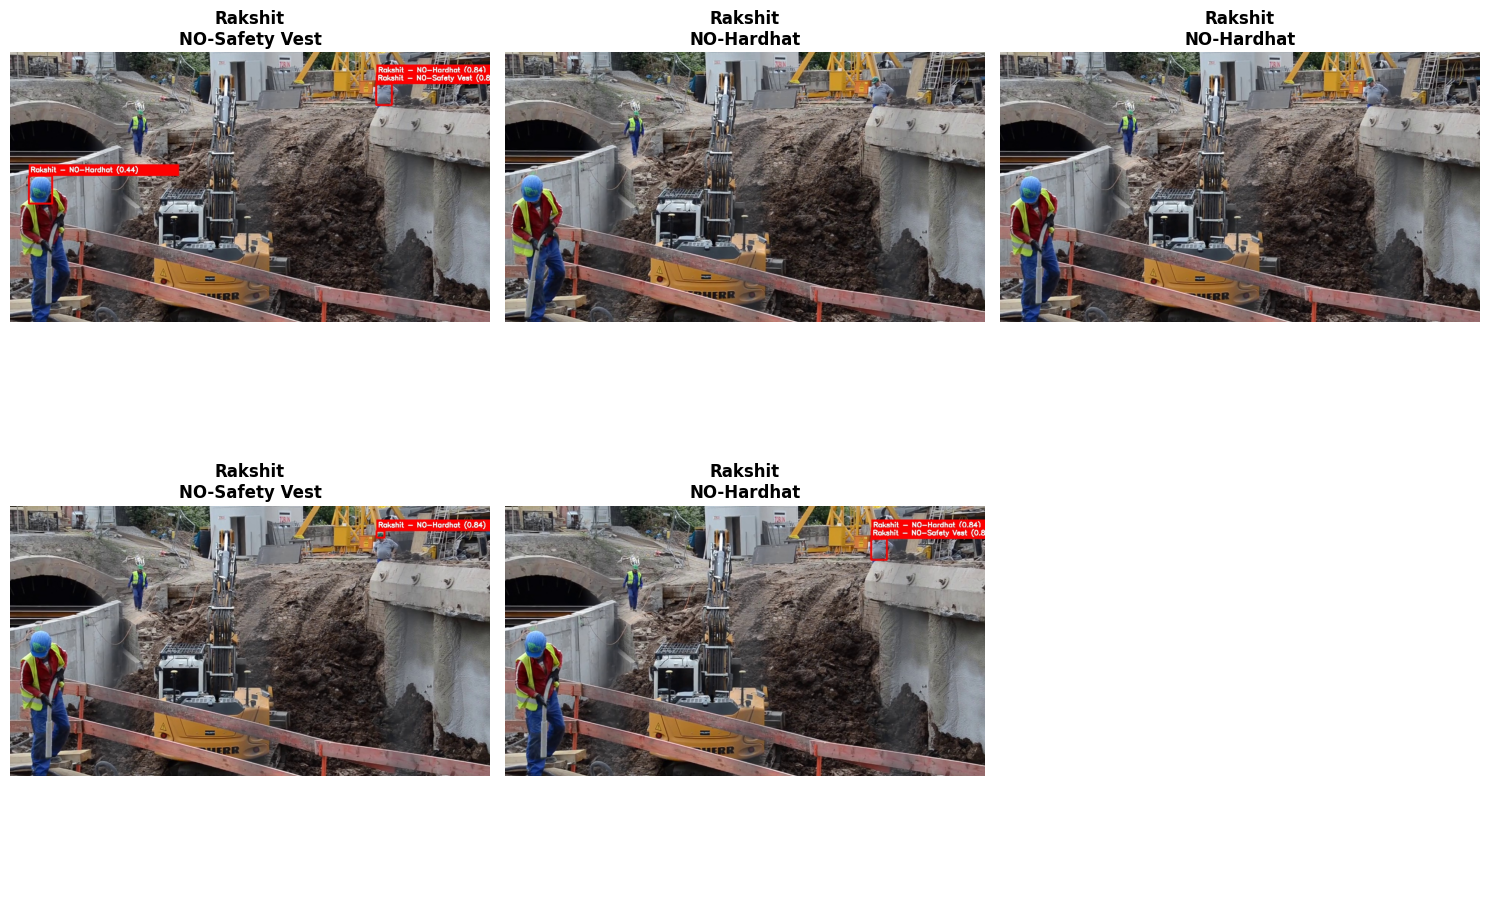

In [88]:
# ============================================================================
# STEP 5: Display Detection Images
# ============================================================================
print('\n\nSTEP 5: DISPLAY SAMPLE DETECTIONS\n')

display_detection_images(num_images=5)

In [67]:
# Export violations to CSV
def export_violations_to_csv():
    conn = sqlite3.connect(Config.DB_PATH)
    query = '''
        SELECT v.violation_id, v.worker_name, w.employee_code, 
               v.violation_type, v.timestamp, v.confidence, 
               v.similarity, v.location, v.status
        FROM violations v
        LEFT JOIN workers w ON v.worker_id = w.worker_id
        ORDER BY v.timestamp DESC
    '''
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    output_file = f'{Config.OUTPUT_DIR}violations_report.csv'
    df.to_csv(output_file, index=False)
    print(f'✅ Violations report exported: {output_file}')
    return df

# Export report
violations_df = export_violations_to_csv()
print(f'\n📊 Total violations in report: {len(violations_df)}')
violations_df.head(10)

✅ Violations report exported: /kaggle/working/violations_report.csv

📊 Total violations in report: 60


,violation_id,worker_name,employee_code,violation_type,timestamp,confidence,similarity,location,status
0,58,Rakshit,None,NO-Mask,2026-01-16 19:43:38,0.628638,0.0,Zone-A,Logged
1,59,Rakshit,None,NO-Hardhat,2026-01-16 19:43:38,0.620317,0.0,Zone-A,Logged
2,60,Rakshit,None,NO-Mask,2026-01-16 19:43:38,0.566145,0.0,Zone-A,Logged
3,55,Rakshit,None,NO-Safety Vest,2026-01-16 19:43:37,0.838782,0.0,Zone-A,Logged
4,56,Rakshit,None,NO-Hardhat,2026-01-16 19:43:37,0.733614,0.0,Zone-A,Logged
5,57,Rakshit,None,NO-Safety Vest,2026-01-16 19:43:37,0.799177,0.0,Zone-A,Logged
6,51,Rakshit,None,NO-Mask,2026-01-16 19:43:36,0.489847,0.0,Zone-A,Logged
7,52,Rakshit,None,NO-Mask,2026-01-16 19:43:36,0.447289,0.0,Zone-A,Logged
8,53,Rakshit,None,NO-Hardhat,2026-01-16 19:43:36,0.337267,0.0,Zone-A,Logged
9,54,Rakshit,None,NO-Mask,2026-01-16 19:43:36,0.267069,0.0,Zone-A,Logged


In [69]:
# Test detection on a single image
def test_single_image(image_path, yolo_model):
    """
    Test PPE detection and face recognition on a single image.
    """
    if not os.path.exists(image_path):
        print(f'❌ Image not found: {image_path}')
        return
    
    print(f'🔍 Testing image: {image_path}\n')
    
    # Read image
    frame = cv2.imread(image_path)
    if frame is None:
        print('❌ Failed to read image')
        return
    
    h, w = frame.shape[:2]
    print(f'Image size: {w}x{h}\n')
    
    annotated = frame.copy()
    
    # Run YOLO detection
    results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)
    
    print('='*70)
    print('DETECTIONS:')
    print('='*70)
    
    for r in results:
        boxes = r.boxes
        print(f'Found {len(boxes)} objects\n')
        
        for i, box in enumerate(boxes, 1):
            cls_id = int(box.cls[0])
            class_name = Config.CLASSES[cls_id]
            confidence = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            print(f'{i}. {class_name} - Confidence: {confidence:.2f}')
            
            # Check if violation
            is_violation = class_name in Config.VIOLATION_CLASSES
            color = (0, 0, 255) if is_violation else (0, 255, 0)
            
            if is_violation:
                print(f'   ⚠️  VIOLATION DETECTED!')
                
                # Try face recognition
                margin = 50
                person_x1 = max(0, x1 - margin)
                person_y1 = max(0, y1 - margin)
                person_x2 = min(w, x2 + margin)
                person_y2 = min(h, y2 + margin)
                
                person_crop = frame[person_y1:person_y2, person_x1:person_x2]
                
                worker_name = Config.DEFAULT_WORKER_NAME
                similarity = 0.0
                
                if person_crop.size > 0 and person_crop.shape[0] > 30 and person_crop.shape[1] > 30:
                    try:
                        matches = recognize_face(person_crop, return_top_n=1)
                        if matches:
                            _, worker_name, emp_code, similarity = matches[0]
                            print(f'   ✓ Recognized: {worker_name} (#{emp_code})')\n                            print(f'   📊 Similarity: {similarity:.2f}')
                        else:
                            print(f'   ℹ️  No match - Using default: {worker_name}')
                    except Exception as e:
                        print(f'   ⚠️  Recognition error: {str(e)[:60]}')
                        print(f'   ℹ️  Using default: {worker_name}')
                
                # Draw with worker name
                label = f'{worker_name} - {class_name}'
                if similarity > 0:
                    label += f' (Match: {similarity:.2f})'
            else:
                label = f'{class_name}'
            
            # Draw bounding box
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)
            
            # Draw label background
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
            cv2.rectangle(annotated, (x1, y1 - 30), (x1 + label_size[0] + 10, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 5, y1 - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            
            print()
    
    print('='*70)
    
    # Display result
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title('Detection Result', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Save result
    output_path = f'{Config.OUTPUT_DIR}test_detection_result.jpg'
    cv2.imwrite(output_path, annotated)
    print(f'\n✅ Result saved: {output_path}')




SyntaxError: unexpected character after line continuation character (2471844752.py, line 66)

In [70]:
# View specific worker's violations
def get_worker_violations(worker_name):
    conn = sqlite3.connect(Config.DB_PATH)
    query = '''
        SELECT violation_type, timestamp, confidence, similarity, location
        FROM violations
        WHERE worker_name = ?
        ORDER BY timestamp DESC
    '''
    df = pd.read_sql_query(query, conn, params=(worker_name,))
    conn.close()
    return df

# List all enrolled workers
def list_all_workers():
    conn = sqlite3.connect(Config.DB_PATH)
    query = 'SELECT worker_id, name, employee_code, enrolled_date FROM workers'
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# View workers
print('📋 Enrolled Workers:')
workers_df = list_all_workers()
print(workers_df)

📋 Enrolled Workers:
   worker_id                   name employee_code        enrolled_date
0          1  Win 20260117 00 03 17           Pro  2026-01-16 18:41:47


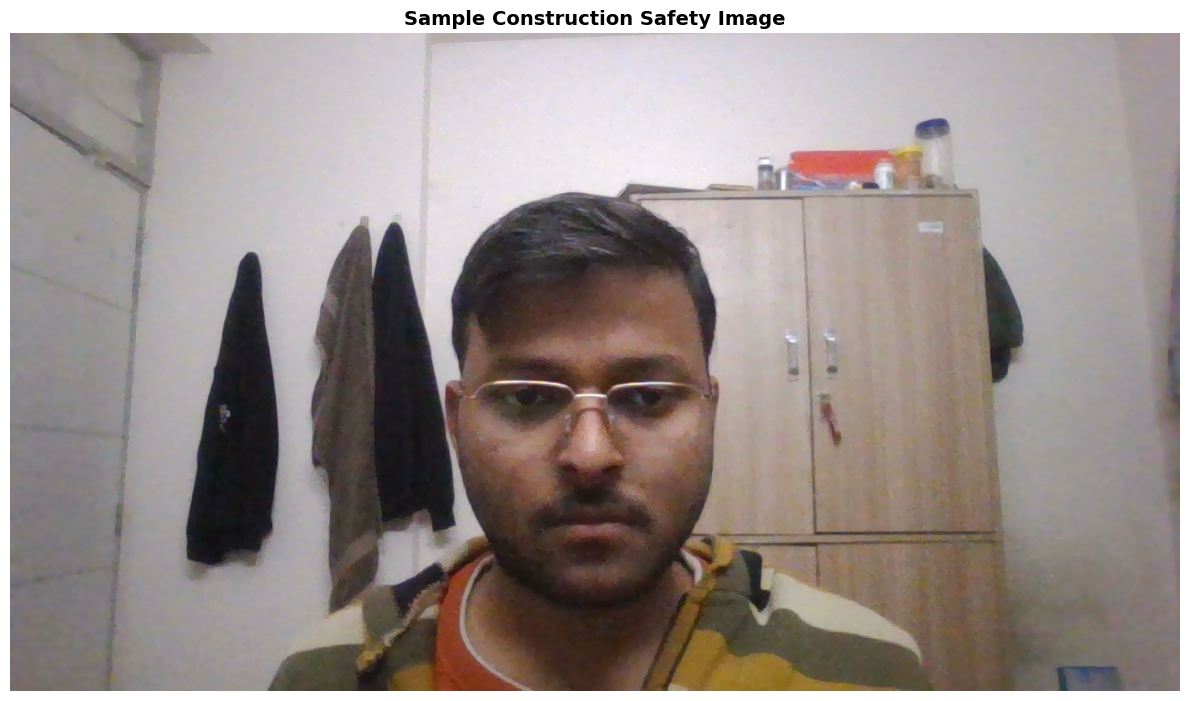

✅ Image loaded successfully
Image size: 1280x720 pixels
Image mode: RGB


In [90]:
# Display a specific image from the dataset
image_path = '/kaggle/input/photos/WIN_20260117_00_03_17_Pro.jpg'

if os.path.exists(image_path):
    # Load and display the image
    img = Image.open(image_path)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Sample Construction Safety Image', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print image info
    print(f'✅ Image loaded successfully')
    print(f'Image size: {img.size[0]}x{img.size[1]} pixels')
    print(f'Image mode: {img.mode}')
else:
    print(f'❌ Image not found at: {image_path}')
    print('Please check the path or upload the image to Kaggle.')

Loading model...
✅ Model loaded
Classes: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

Running detection...
Results saved to /kaggle/working/sample_detection/result
✅ Detection complete!

Total detections: 4

Detected objects:
  • NO-Hardhat: 1 (avg confidence: 90.64%)
  • Person: 1 (avg confidence: 89.85%)
  • NO-Mask: 1 (avg confidence: 89.55%)
  • NO-Safety Vest: 1 (avg confidence: 86.46%)

Detection Result:


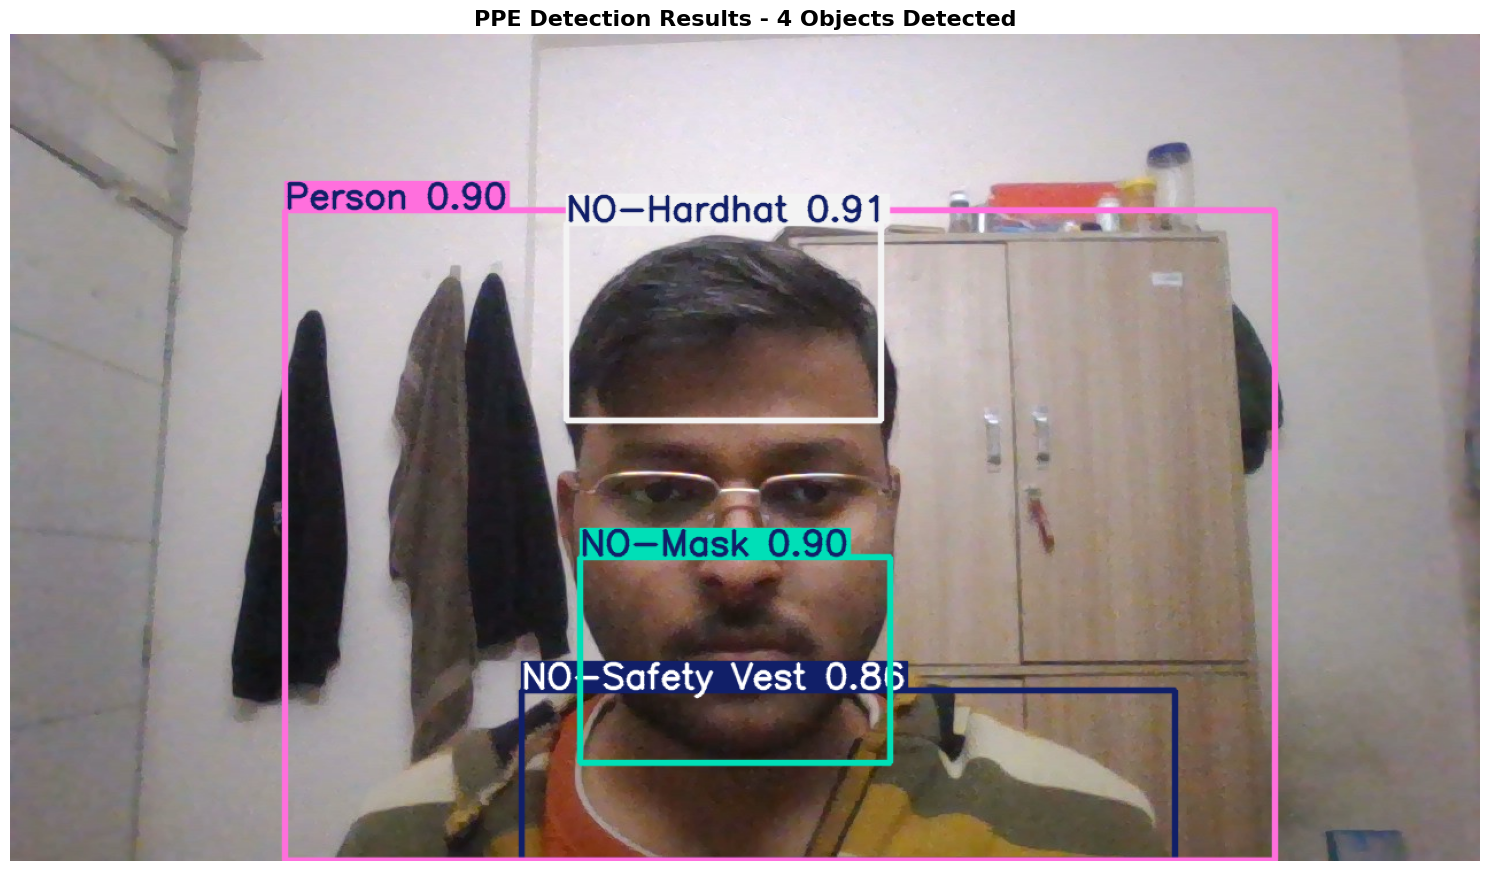

In [92]:
# Load model and run detection on the construction safety image
image_path = '/kaggle/input/photos/WIN_20260117_00_03_17_Pro.jpg'
model_path = '/kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt'

if os.path.exists(image_path) and os.path.exists(model_path):
    # Load model
    print('Loading model...')
    model = YOLO(model_path)
    print('✅ Model loaded')
    
    # Get class names
    CLASSES = list(model.names.values())
    print(f'Classes: {CLASSES}\n')
    
    # Run detection
    print('Running detection...')
    results = model.predict(
        source=image_path,
        conf=0.25,  # Confidence threshold
        iou=0.45,   # NMS IoU threshold
        imgsz=640,
        device=[0] if os.path.exists('/dev/nvidia0') else 'cpu',
        save=True,
        save_txt=False,
        exist_ok=True,
        project='/kaggle/working/sample_detection',
        name='result',
        verbose=False
    )
    
    # Display results
    print('✅ Detection complete!\n')
    
    # Print detection details
    for r in results:
        num_detections = len(r.boxes)
        print(f'Total detections: {num_detections}\n')
        
        if num_detections > 0:
            print('Detected objects:')
            detections_by_class = {}
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                cls_name = CLASSES[cls_id]
                
                if cls_name not in detections_by_class:
                    detections_by_class[cls_name] = []
                detections_by_class[cls_name].append(conf)
            
            for cls_name, confs in detections_by_class.items():
                avg_conf = np.mean(confs)
                print(f'  • {cls_name}: {len(confs)} (avg confidence: {avg_conf:.2%})')
        else:
            print('No objects detected')
    
    # Display the result image with bounding boxes
    print('\n' + '='*70)
    print('Detection Result:')
    print('='*70)
    
    result_img_path = '/kaggle/working/sample_detection/result/construction-safety.jpg'
    if os.path.exists(result_img_path):
        result_img = Image.open(result_img_path)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(result_img)
        plt.axis('off')
        plt.title(f'PPE Detection Results - {num_detections} Objects Detected', 
                 fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        # Display using results object
        annotated_frame = results[0].plot()
        annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(annotated_frame_rgb)
        plt.axis('off')
        plt.title(f'PPE Detection Results - {num_detections} Objects Detected', 
                 fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
else:
    if not os.path.exists(image_path):
        print(f'❌ Image not found: {image_path}')
    if not os.path.exists(model_path):
        print(f'❌ Model not found: {model_path}')

🔍 TESTING YOUR SPECIFIC PHOTO
Image: /kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg

✅ Image loaded: 1280x720 pixels

🤖 Running YOLO detection...

📋 DETECTION RESULTS:
Found 5 object(s)

1. NO-Hardhat - Confidence: 0.93
   🚨 VIOLATION DETECTED: NO-Hardhat
   🔍 Attempting face recognition...
   ℹ️  No match above threshold (0.7)
   📝 Using default name: Rakshit

2. NO-Mask - Confidence: 0.89
   🚨 VIOLATION DETECTED: NO-Mask
   🔍 Attempting face recognition...
   ✅ FACE RECOGNIZED!
   👤 Worker: Win 20260117 00 03 17 (Employee #Pro)
   📊 Similarity Score: 0.7655
   🎯 Match Quality: GOOD
   📷 Enrolled Photo: WIN_20260117_00_03_17_Pro.jpg

3. Person - Confidence: 0.88
   ✅ Compliant: Person

4. NO-Safety Vest - Confidence: 0.56
   🚨 VIOLATION DETECTED: NO-Safety Vest
   🔍 Attempting face recognition...
   ℹ️  No match above threshold (0.7)
   📝 Using default name: Rakshit

5. NO-Safety Vest - Confidence: 0.53
   🚨 VIOLATION DETECTED: NO-Safety Vest
   🔍 Attempting face recognition...
 

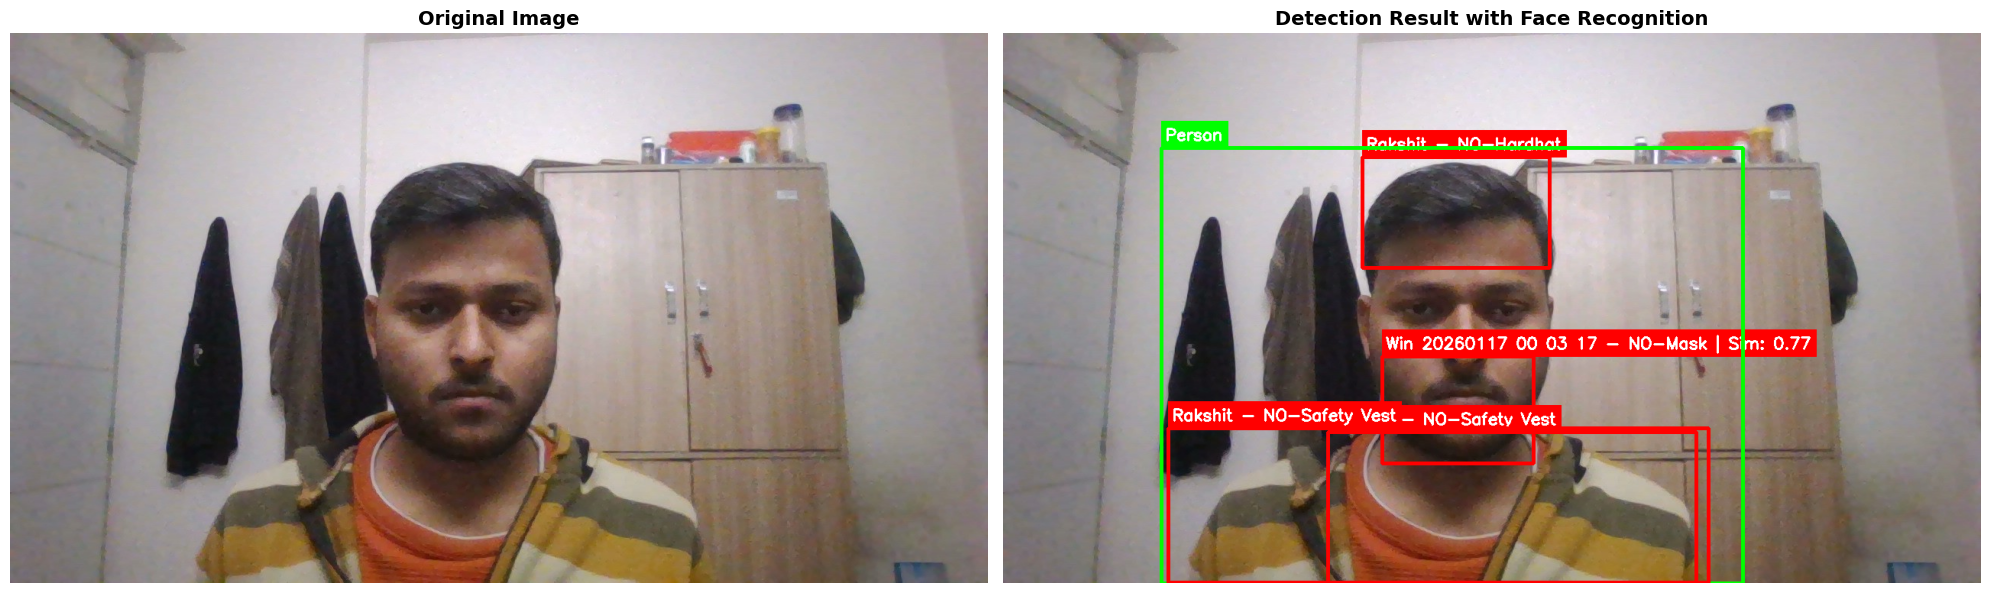

✅ Result saved: /kaggle/working/test_specific_photo_result.jpg


In [93]:
# ============================================================================
# TEST YOUR SPECIFIC PHOTO WITH SIMILARITY COMPARISON
# ============================================================================

TEST_IMAGE_PATH = '/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg'

print('='*70)
print('🔍 TESTING YOUR SPECIFIC PHOTO')
print('='*70)
print(f'Image: {TEST_IMAGE_PATH}\n')

if not os.path.exists(TEST_IMAGE_PATH):
    print(f'❌ Image not found: {TEST_IMAGE_PATH}')
    print('Please check the path and try again!')
else:
    # Read image
    frame = cv2.imread(TEST_IMAGE_PATH)
    if frame is None:
        print('❌ Failed to read image')
    else:
        h, w = frame.shape[:2]
        print(f'✅ Image loaded: {w}x{h} pixels\n')
        
        annotated = frame.copy()
        
        # Run YOLO detection
        print('🤖 Running YOLO detection...\n')
        results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)
        
        print('='*70)
        print('📋 DETECTION RESULTS:')
        print('='*70)
        
        violation_found = False
        
        for r in results:
            boxes = r.boxes
            
            if len(boxes) == 0:
                print('⚠️  No objects detected in image!')
            else:
                print(f'Found {len(boxes)} object(s)\n')
            
            for i, box in enumerate(boxes, 1):
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                print(f'{i}. {class_name} - Confidence: {confidence:.2f}')
                
                # Check if violation
                is_violation = class_name in Config.VIOLATION_CLASSES
                color = (0, 0, 255) if is_violation else (0, 255, 0)
                
                if is_violation:
                    violation_found = True
                    print(f'   🚨 VIOLATION DETECTED: {class_name}')
                    
                    # Try face recognition with similarity
                    margin = 50
                    person_x1 = max(0, x1 - margin)
                    person_y1 = max(0, y1 - margin)
                    person_x2 = min(w, x2 + margin)
                    person_y2 = min(h, y2 + margin)
                    
                    person_crop = frame[person_y1:person_y2, person_x1:person_x2]
                    
                    worker_name = Config.DEFAULT_WORKER_NAME
                    similarity = 0.0
                    match_status = "No Match"
                    
                    if person_crop.size > 0 and person_crop.shape[0] > 30 and person_crop.shape[1] > 30:
                        try:
                            print(f'   🔍 Attempting face recognition...')
                            matches = recognize_face(person_crop, return_top_n=1)
                            
                            if matches:
                                worker_id, worker_name, emp_code, similarity = matches[0]
                                match_status = "MATCHED"
                                print(f'   ✅ FACE RECOGNIZED!')
                                print(f'   👤 Worker: {worker_name} (Employee #{emp_code})')
                                print(f'   📊 Similarity Score: {similarity:.4f}')
                                print(f'   🎯 Match Quality: {"EXCELLENT" if similarity > 0.80 else "GOOD" if similarity > 0.70 else "FAIR"}')
                                
                                # Compare with enrolled photo
                                conn = sqlite3.connect(Config.DB_PATH)
                                cursor = conn.cursor()
                                cursor.execute('SELECT photo_path FROM workers WHERE worker_id = ?', (worker_id,))
                                result = cursor.fetchone()
                                conn.close()
                                
                                if result and result[0]:
                                    print(f'   📷 Enrolled Photo: {os.path.basename(result[0])}')
                            else:
                                match_status = "Below Threshold"
                                print(f'   ℹ️  No match above threshold ({Config.SIMILARITY_THRESHOLD})')
                                print(f'   📝 Using default name: {worker_name}')
                        except Exception as e:
                            print(f'   ⚠️  Face recognition error: {str(e)[:100]}')
                            print(f'   📝 Using default name: {worker_name}')
                    else:
                        print(f'   ⚠️  Face crop too small for recognition')
                        print(f'   📝 Using default name: {worker_name}')
                    
                    # Draw with worker name
                    label = f'{worker_name} - {class_name}'
                    if similarity > 0:
                        label += f' | Sim: {similarity:.2f}'
                else:
                    label = f'{class_name}'
                    print(f'   ✅ Compliant: {class_name}')
                
                # Draw bounding box
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)
                
                # Draw label background
                label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0]
                cv2.rectangle(annotated, (x1, y1 - 35), (x1 + label_size[0] + 10, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 5, y1 - 10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                
                print()
        
        print('='*70)
        
        if violation_found:
            print('\n⚠️  SUMMARY: PPE VIOLATIONS DETECTED!')
        else:
            print('\n✅ SUMMARY: No violations - All PPE compliant!')
        
        print('='*70)
        
        # Display result
        print('\n📸 Displaying detection result...\n')
        
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        
        # Original image
        axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        # Annotated image
        axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[1].set_title('Detection Result with Face Recognition', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Save result
        output_path = f'{Config.OUTPUT_DIR}test_specific_photo_result.jpg'
        cv2.imwrite(output_path, annotated)
        print(f'✅ Result saved: {output_path}')
        print('='*70)

🔬 PHOTO COMPARISON & SIMILARITY ANALYSIS
📷 Enrolled Photo: /kaggle/input/photos/WIN_20260117_00_03_17_Pro.jpg
📷 Test Photo: /kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg

✅ Both images loaded successfully

STEP 1: COMPUTING FACE SIMILARITY
🔍 Extracting face embeddings from enrolled photo...
🔍 Extracting face embeddings from test photo...

📊 SIMILARITY RESULTS:
✨ Similarity Score: 0.897900
📈 Percentage Match: 89.79%
🎯 Match Quality: EXCELLENT ⭐⭐⭐
✅ Verdict: SAME PERSON - HIGH CONFIDENCE
🔢 Threshold: 0.7 (PASS ✓)

STEP 2: RUNNING PPE DETECTION ON BOTH PHOTOS

📷 Processing ENROLLED PHOTO:
----------------------------------------------------------------------
Found 4 object(s)
  1. 🚨 NO-Hardhat (Conf: 0.91)
  2. ✓ Person (Conf: 0.90)
  3. 🚨 NO-Mask (Conf: 0.90)
  4. 🚨 NO-Safety Vest (Conf: 0.86)

📷 Processing TEST PHOTO:
----------------------------------------------------------------------
Found 5 object(s)
  1. 🚨 NO-Hardhat (Conf: 0.93)
  2. 🚨 NO-Mask (Conf: 0.89)
  3. ✓ Person (Co

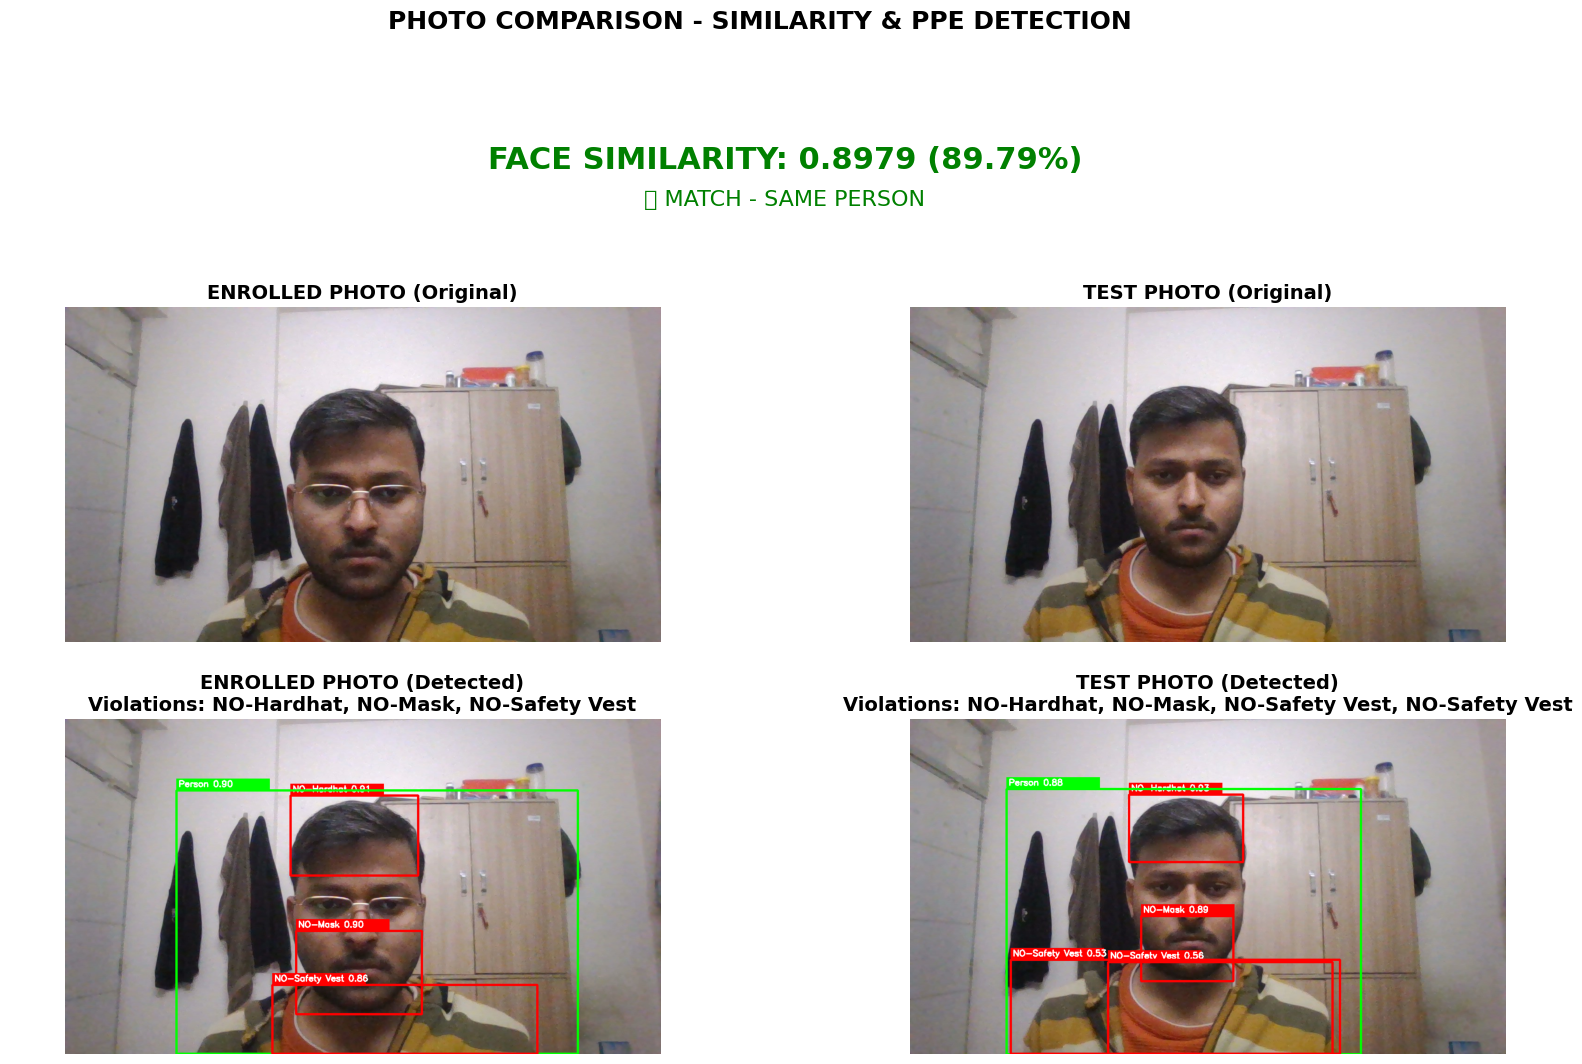


📋 FINAL SUMMARY
🔬 Face Similarity: 0.8979 (89.79%)
🎯 Match Status: ✅ PASS

📷 Enrolled Photo Violations: 3
   - NO-Safety Vest
   - NO-Hardhat
   - NO-Mask

📷 Test Photo Violations: 4
   - NO-Safety Vest
   - NO-Hardhat
   - NO-Mask

✅ Comparison saved: /kaggle/working/photo_comparison_result.jpg


<Figure size 640x480 with 0 Axes>

In [94]:
# ============================================================================
# COMPARE TWO PHOTOS - SIMILARITY ANALYSIS & DETECTION
# ============================================================================

ENROLLED_PHOTO = '/kaggle/input/photos/WIN_20260117_00_03_17_Pro.jpg'
TEST_PHOTO = '/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg'

print('='*70)
print('🔬 PHOTO COMPARISON & SIMILARITY ANALYSIS')
print('='*70)
print(f'📷 Enrolled Photo: {ENROLLED_PHOTO}')
print(f'📷 Test Photo: {TEST_PHOTO}')
print('='*70 + '\n')

# Check if both files exist
if not os.path.exists(ENROLLED_PHOTO):
    print(f'❌ Enrolled photo not found: {ENROLLED_PHOTO}')
elif not os.path.exists(TEST_PHOTO):
    print(f'❌ Test photo not found: {TEST_PHOTO}')
else:
    # Load both images
    enrolled_img = cv2.imread(ENROLLED_PHOTO)
    test_img = cv2.imread(TEST_PHOTO)
    
    if enrolled_img is None or test_img is None:
        print('❌ Failed to load one or both images')
    else:
        print('✅ Both images loaded successfully\n')
        
        # ========== STEP 1: COMPUTE FACE SIMILARITY ==========
        print('='*70)
        print('STEP 1: COMPUTING FACE SIMILARITY')
        print('='*70)
        
        try:
            # Extract embeddings from both photos
            print('🔍 Extracting face embeddings from enrolled photo...')
            enrolled_embedding = extract_face_embedding(ENROLLED_PHOTO)
            
            print('🔍 Extracting face embeddings from test photo...')
            test_embedding = extract_face_embedding(TEST_PHOTO)
            
            if enrolled_embedding is not None and test_embedding is not None:
                # Calculate similarity
                enrolled_emb_array = np.array(enrolled_embedding)
                test_emb_array = np.array(test_embedding)
                similarity_score = cosine_similarity(enrolled_emb_array, test_emb_array)
                
                print('\n' + '='*70)
                print('📊 SIMILARITY RESULTS:')
                print('='*70)
                print(f'✨ Similarity Score: {similarity_score:.6f}')
                print(f'📈 Percentage Match: {similarity_score * 100:.2f}%')
                
                if similarity_score >= 0.80:
                    quality = "EXCELLENT ⭐⭐⭐"
                    match_verdict = "SAME PERSON - HIGH CONFIDENCE"
                elif similarity_score >= 0.70:
                    quality = "GOOD ⭐⭐"
                    match_verdict = "SAME PERSON - MEDIUM CONFIDENCE"
                elif similarity_score >= 0.60:
                    quality = "FAIR ⭐"
                    match_verdict = "POSSIBLE MATCH - LOW CONFIDENCE"
                else:
                    quality = "POOR ❌"
                    match_verdict = "DIFFERENT PERSON"
                
                print(f'🎯 Match Quality: {quality}')
                print(f'✅ Verdict: {match_verdict}')
                print(f'🔢 Threshold: {Config.SIMILARITY_THRESHOLD} ({"PASS ✓" if similarity_score >= Config.SIMILARITY_THRESHOLD else "FAIL ✗"})')
                print('='*70 + '\n')
            else:
                similarity_score = 0.0
                print('⚠️ Could not extract embeddings from one or both photos\n')
        except Exception as e:
            similarity_score = 0.0
            print(f'⚠️ Similarity computation failed: {str(e)}\n')
        
        # ========== STEP 2: RUN DETECTION ON BOTH PHOTOS ==========
        print('='*70)
        print('STEP 2: RUNNING PPE DETECTION ON BOTH PHOTOS')
        print('='*70 + '\n')
        
        # Process enrolled photo
        print('📷 Processing ENROLLED PHOTO:')
        print('-'*70)
        enrolled_annotated = enrolled_img.copy()
        enrolled_results = yolo_model.predict(enrolled_img, conf=Config.CONF_THRESHOLD, verbose=False)
        enrolled_violations = []
        
        for r in enrolled_results:
            boxes = r.boxes
            print(f'Found {len(boxes)} object(s)')
            
            for i, box in enumerate(boxes, 1):
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                is_violation = class_name in Config.VIOLATION_CLASSES
                color = (0, 0, 255) if is_violation else (0, 255, 0)
                
                if is_violation:
                    enrolled_violations.append(class_name)
                    print(f'  {i}. 🚨 {class_name} (Conf: {confidence:.2f})')
                else:
                    print(f'  {i}. ✓ {class_name} (Conf: {confidence:.2f})')
                
                # Draw detection
                cv2.rectangle(enrolled_annotated, (x1, y1), (x2, y2), color, 3)
                label = f'{class_name} {confidence:.2f}'
                cv2.rectangle(enrolled_annotated, (x1, y1 - 25), (x1 + 200, y1), color, -1)
                cv2.putText(enrolled_annotated, label, (x1 + 5, y1 - 8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        print()
        
        # Process test photo
        print('📷 Processing TEST PHOTO:')
        print('-'*70)
        test_annotated = test_img.copy()
        test_results = yolo_model.predict(test_img, conf=Config.CONF_THRESHOLD, verbose=False)
        test_violations = []
        
        for r in test_results:
            boxes = r.boxes
            print(f'Found {len(boxes)} object(s)')
            
            for i, box in enumerate(boxes, 1):
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                is_violation = class_name in Config.VIOLATION_CLASSES
                color = (0, 0, 255) if is_violation else (0, 255, 0)
                
                if is_violation:
                    test_violations.append(class_name)
                    print(f'  {i}. 🚨 {class_name} (Conf: {confidence:.2f})')
                else:
                    print(f'  {i}. ✓ {class_name} (Conf: {confidence:.2f})')
                
                # Draw detection
                cv2.rectangle(test_annotated, (x1, y1), (x2, y2), color, 3)
                label = f'{class_name} {confidence:.2f}'
                cv2.rectangle(test_annotated, (x1, y1 - 25), (x1 + 200, y1), color, -1)
                cv2.putText(test_annotated, label, (x1 + 5, y1 - 8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        print('\n' + '='*70)
        
        # ========== STEP 3: DISPLAY COMPARISON ==========
        print('STEP 3: DISPLAYING VISUAL COMPARISON')
        print('='*70 + '\n')
        
        # Create comparison display
        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 2, height_ratios=[0.3, 1, 1], hspace=0.3, wspace=0.2)
        
        # Similarity score banner (spans both columns)
        ax_banner = fig.add_subplot(gs[0, :])
        ax_banner.axis('off')
        banner_text = f'FACE SIMILARITY: {similarity_score:.4f} ({similarity_score*100:.2f}%)'
        if similarity_score >= Config.SIMILARITY_THRESHOLD:
            banner_color = 'green'
            result_text = '✅ MATCH - SAME PERSON'
        else:
            banner_color = 'orange'
            result_text = '⚠️ BELOW THRESHOLD'
        
        ax_banner.text(0.5, 0.7, banner_text, fontsize=22, fontweight='bold', 
                      ha='center', va='center', color=banner_color)
        ax_banner.text(0.5, 0.3, result_text, fontsize=16, ha='center', va='center', color=banner_color)
        
        # Enrolled photo - Original
        ax1 = fig.add_subplot(gs[1, 0])
        ax1.imshow(cv2.cvtColor(enrolled_img, cv2.COLOR_BGR2RGB))
        ax1.set_title('ENROLLED PHOTO (Original)', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Test photo - Original
        ax2 = fig.add_subplot(gs[1, 1])
        ax2.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
        ax2.set_title('TEST PHOTO (Original)', fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        # Enrolled photo - With detections
        ax3 = fig.add_subplot(gs[2, 0])
        ax3.imshow(cv2.cvtColor(enrolled_annotated, cv2.COLOR_BGR2RGB))
        violation_text = f"Violations: {', '.join(enrolled_violations)}" if enrolled_violations else "No Violations ✓"
        ax3.set_title(f'ENROLLED PHOTO (Detected)\n{violation_text}', fontsize=14, fontweight='bold')
        ax3.axis('off')
        
        # Test photo - With detections
        ax4 = fig.add_subplot(gs[2, 1])
        ax4.imshow(cv2.cvtColor(test_annotated, cv2.COLOR_BGR2RGB))
        violation_text = f"Violations: {', '.join(test_violations)}" if test_violations else "No Violations ✓"
        ax4.set_title(f'TEST PHOTO (Detected)\n{violation_text}', fontsize=14, fontweight='bold')
        ax4.axis('off')
        
        plt.suptitle('PHOTO COMPARISON - SIMILARITY & PPE DETECTION', 
                    fontsize=18, fontweight='bold', y=0.98)
        plt.show()
        
        # ========== FINAL SUMMARY ==========
        print('\n' + '='*70)
        print('📋 FINAL SUMMARY')
        print('='*70)
        print(f'🔬 Face Similarity: {similarity_score:.4f} ({similarity_score*100:.2f}%)')
        print(f'🎯 Match Status: {"✅ PASS" if similarity_score >= Config.SIMILARITY_THRESHOLD else "❌ FAIL"}')
        print(f'\n📷 Enrolled Photo Violations: {len(enrolled_violations)}')
        if enrolled_violations:
            for v in set(enrolled_violations):
                print(f'   - {v}')
        print(f'\n📷 Test Photo Violations: {len(test_violations)}')
        if test_violations:
            for v in set(test_violations):
                print(f'   - {v}')
        print('='*70)
        
        # Save results
        output_path = f'{Config.OUTPUT_DIR}photo_comparison_result.jpg'
        plt.savefig(output_path, bbox_inches='tight', dpi=150)
        print(f'\n✅ Comparison saved: {output_path}')
        print('='*70)

🔬 PHOTO COMPARISON & SIMILARITY ANALYSIS
📷 Enrolled Photo: /kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg
📷 Test Photo: /kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg

✅ Both images loaded successfully

STEP 1: COMPUTING FACE SIMILARITY
🔍 Extracting face embeddings from enrolled photo...
🔍 Extracting face embeddings from test photo...

📊 SIMILARITY RESULTS:
✨ Similarity Score: 0.369689
📈 Percentage Match: 36.97%
🎯 Match Quality: POOR ❌
✅ Verdict: DIFFERENT PERSON
🔢 Threshold: 0.7 (FAIL ✗)

STEP 2: RUNNING PPE DETECTION ON BOTH PHOTOS

📷 Processing ENROLLED PHOTO:
----------------------------------------------------------------------
Found 4 object(s)
  1. 🚨 NO-Hardhat (Conf: 0.93)
  2. 🚨 NO-Safety Vest (Conf: 0.91)
  3. ✓ Person (Conf: 0.91)
  4. 🚨 NO-Mask (Conf: 0.88)

📷 Processing TEST PHOTO:
----------------------------------------------------------------------
Found 5 object(s)
  1. 🚨 NO-Hardhat (Conf: 0.93)
  2. 🚨 NO-Mask (Conf: 0.89)
  3. ✓ Person (Conf: 0.88)
  4. 🚨 N

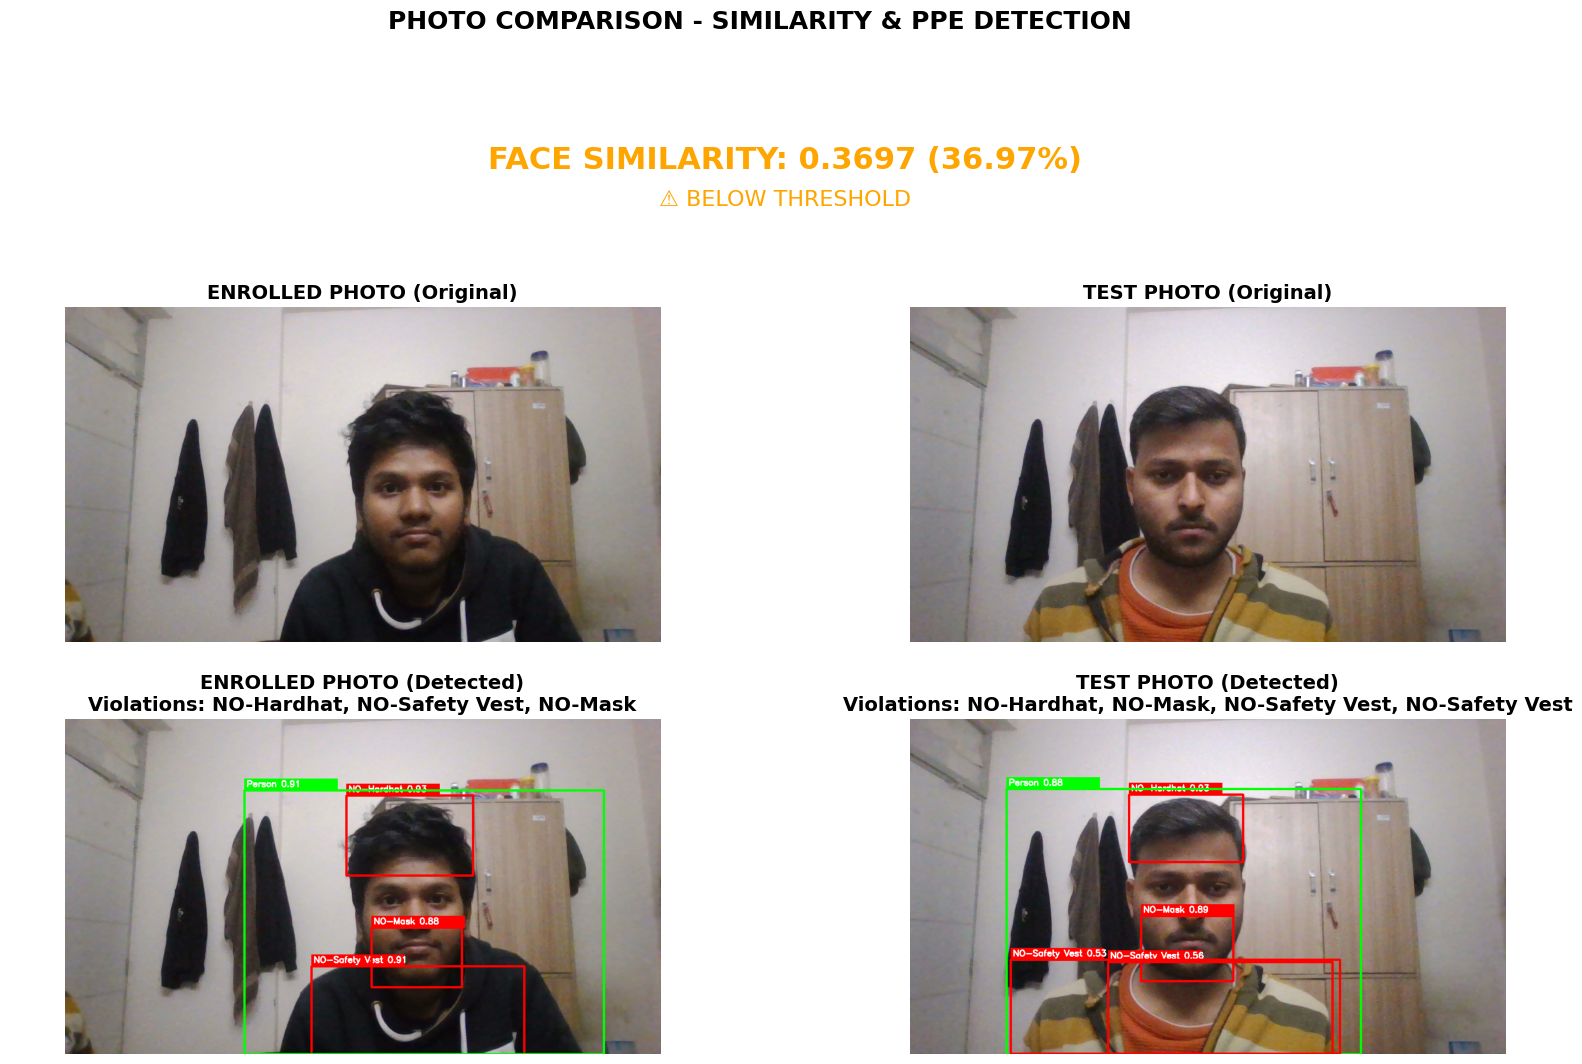


📋 FINAL SUMMARY
🔬 Face Similarity: 0.3697 (36.97%)
🎯 Match Status: ❌ FAIL

📷 Enrolled Photo Violations: 3
   - NO-Safety Vest
   - NO-Hardhat
   - NO-Mask

📷 Test Photo Violations: 4
   - NO-Safety Vest
   - NO-Hardhat
   - NO-Mask

✅ Comparison saved: /kaggle/working/photo_comparison_result.jpg


<Figure size 640x480 with 0 Axes>

In [95]:
# ============================================================================
# COMPARE TWO PHOTOS - SIMILARITY ANALYSIS & DETECTION
# ============================================================================

ENROLLED_PHOTO = '/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg'
TEST_PHOTO = '/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg'

print('='*70)
print('🔬 PHOTO COMPARISON & SIMILARITY ANALYSIS')
print('='*70)
print(f'📷 Enrolled Photo: {ENROLLED_PHOTO}')
print(f'📷 Test Photo: {TEST_PHOTO}')
print('='*70 + '\n')

# Check if both files exist
if not os.path.exists(ENROLLED_PHOTO):
    print(f'❌ Enrolled photo not found: {ENROLLED_PHOTO}')
elif not os.path.exists(TEST_PHOTO):
    print(f'❌ Test photo not found: {TEST_PHOTO}')
else:
    # Load both images
    enrolled_img = cv2.imread(ENROLLED_PHOTO)
    test_img = cv2.imread(TEST_PHOTO)
    
    if enrolled_img is None or test_img is None:
        print('❌ Failed to load one or both images')
    else:
        print('✅ Both images loaded successfully\n')
        
        # ========== STEP 1: COMPUTE FACE SIMILARITY ==========
        print('='*70)
        print('STEP 1: COMPUTING FACE SIMILARITY')
        print('='*70)
        
        try:
            # Extract embeddings from both photos
            print('🔍 Extracting face embeddings from enrolled photo...')
            enrolled_embedding = extract_face_embedding(ENROLLED_PHOTO)
            
            print('🔍 Extracting face embeddings from test photo...')
            test_embedding = extract_face_embedding(TEST_PHOTO)
            
            if enrolled_embedding is not None and test_embedding is not None:
                # Calculate similarity
                enrolled_emb_array = np.array(enrolled_embedding)
                test_emb_array = np.array(test_embedding)
                similarity_score = cosine_similarity(enrolled_emb_array, test_emb_array)
                
                print('\n' + '='*70)
                print('📊 SIMILARITY RESULTS:')
                print('='*70)
                print(f'✨ Similarity Score: {similarity_score:.6f}')
                print(f'📈 Percentage Match: {similarity_score * 100:.2f}%')
                
                if similarity_score >= 0.80:
                    quality = "EXCELLENT ⭐⭐⭐"
                    match_verdict = "SAME PERSON - HIGH CONFIDENCE"
                elif similarity_score >= 0.70:
                    quality = "GOOD ⭐⭐"
                    match_verdict = "SAME PERSON - MEDIUM CONFIDENCE"
                elif similarity_score >= 0.60:
                    quality = "FAIR ⭐"
                    match_verdict = "POSSIBLE MATCH - LOW CONFIDENCE"
                else:
                    quality = "POOR ❌"
                    match_verdict = "DIFFERENT PERSON"
                
                print(f'🎯 Match Quality: {quality}')
                print(f'✅ Verdict: {match_verdict}')
                print(f'🔢 Threshold: {Config.SIMILARITY_THRESHOLD} ({"PASS ✓" if similarity_score >= Config.SIMILARITY_THRESHOLD else "FAIL ✗"})')
                print('='*70 + '\n')
            else:
                similarity_score = 0.0
                print('⚠️ Could not extract embeddings from one or both photos\n')
        except Exception as e:
            similarity_score = 0.0
            print(f'⚠️ Similarity computation failed: {str(e)}\n')
        
        # ========== STEP 2: RUN DETECTION ON BOTH PHOTOS ==========
        print('='*70)
        print('STEP 2: RUNNING PPE DETECTION ON BOTH PHOTOS')
        print('='*70 + '\n')
        
        # Process enrolled photo
        print('📷 Processing ENROLLED PHOTO:')
        print('-'*70)
        enrolled_annotated = enrolled_img.copy()
        enrolled_results = yolo_model.predict(enrolled_img, conf=Config.CONF_THRESHOLD, verbose=False)
        enrolled_violations = []
        
        for r in enrolled_results:
            boxes = r.boxes
            print(f'Found {len(boxes)} object(s)')
            
            for i, box in enumerate(boxes, 1):
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                is_violation = class_name in Config.VIOLATION_CLASSES
                color = (0, 0, 255) if is_violation else (0, 255, 0)
                
                if is_violation:
                    enrolled_violations.append(class_name)
                    print(f'  {i}. 🚨 {class_name} (Conf: {confidence:.2f})')
                else:
                    print(f'  {i}. ✓ {class_name} (Conf: {confidence:.2f})')
                
                # Draw detection
                cv2.rectangle(enrolled_annotated, (x1, y1), (x2, y2), color, 3)
                label = f'{class_name} {confidence:.2f}'
                cv2.rectangle(enrolled_annotated, (x1, y1 - 25), (x1 + 200, y1), color, -1)
                cv2.putText(enrolled_annotated, label, (x1 + 5, y1 - 8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        print()
        
        # Process test photo
        print('📷 Processing TEST PHOTO:')
        print('-'*70)
        test_annotated = test_img.copy()
        test_results = yolo_model.predict(test_img, conf=Config.CONF_THRESHOLD, verbose=False)
        test_violations = []
        
        for r in test_results:
            boxes = r.boxes
            print(f'Found {len(boxes)} object(s)')
            
            for i, box in enumerate(boxes, 1):
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                confidence = float(box.conf[0])
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                
                is_violation = class_name in Config.VIOLATION_CLASSES
                color = (0, 0, 255) if is_violation else (0, 255, 0)
                
                if is_violation:
                    test_violations.append(class_name)
                    print(f'  {i}. 🚨 {class_name} (Conf: {confidence:.2f})')
                else:
                    print(f'  {i}. ✓ {class_name} (Conf: {confidence:.2f})')
                
                # Draw detection
                cv2.rectangle(test_annotated, (x1, y1), (x2, y2), color, 3)
                label = f'{class_name} {confidence:.2f}'
                cv2.rectangle(test_annotated, (x1, y1 - 25), (x1 + 200, y1), color, -1)
                cv2.putText(test_annotated, label, (x1 + 5, y1 - 8), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        print('\n' + '='*70)
        
        # ========== STEP 3: DISPLAY COMPARISON ==========
        print('STEP 3: DISPLAYING VISUAL COMPARISON')
        print('='*70 + '\n')
        
        # Create comparison display
        fig = plt.figure(figsize=(20, 12))
        gs = fig.add_gridspec(3, 2, height_ratios=[0.3, 1, 1], hspace=0.3, wspace=0.2)
        
        # Similarity score banner (spans both columns)
        ax_banner = fig.add_subplot(gs[0, :])
        ax_banner.axis('off')
        banner_text = f'FACE SIMILARITY: {similarity_score:.4f} ({similarity_score*100:.2f}%)'
        if similarity_score >= Config.SIMILARITY_THRESHOLD:
            banner_color = 'green'
            result_text = '✅ MATCH - SAME PERSON'
        else:
            banner_color = 'orange'
            result_text = '⚠️ BELOW THRESHOLD'
        
        ax_banner.text(0.5, 0.7, banner_text, fontsize=22, fontweight='bold', 
                      ha='center', va='center', color=banner_color)
        ax_banner.text(0.5, 0.3, result_text, fontsize=16, ha='center', va='center', color=banner_color)
        
        # Enrolled photo - Original
        ax1 = fig.add_subplot(gs[1, 0])
        ax1.imshow(cv2.cvtColor(enrolled_img, cv2.COLOR_BGR2RGB))
        ax1.set_title('ENROLLED PHOTO (Original)', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Test photo - Original
        ax2 = fig.add_subplot(gs[1, 1])
        ax2.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
        ax2.set_title('TEST PHOTO (Original)', fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        # Enrolled photo - With detections
        ax3 = fig.add_subplot(gs[2, 0])
        ax3.imshow(cv2.cvtColor(enrolled_annotated, cv2.COLOR_BGR2RGB))
        violation_text = f"Violations: {', '.join(enrolled_violations)}" if enrolled_violations else "No Violations ✓"
        ax3.set_title(f'ENROLLED PHOTO (Detected)\n{violation_text}', fontsize=14, fontweight='bold')
        ax3.axis('off')
        
        # Test photo - With detections
        ax4 = fig.add_subplot(gs[2, 1])
        ax4.imshow(cv2.cvtColor(test_annotated, cv2.COLOR_BGR2RGB))
        violation_text = f"Violations: {', '.join(test_violations)}" if test_violations else "No Violations ✓"
        ax4.set_title(f'TEST PHOTO (Detected)\n{violation_text}', fontsize=14, fontweight='bold')
        ax4.axis('off')
        
        plt.suptitle('PHOTO COMPARISON - SIMILARITY & PPE DETECTION', 
                    fontsize=18, fontweight='bold', y=0.98)
        plt.show()
        
        # ========== FINAL SUMMARY ==========
        print('\n' + '='*70)
        print('📋 FINAL SUMMARY')
        print('='*70)
        print(f'🔬 Face Similarity: {similarity_score:.4f} ({similarity_score*100:.2f}%)')
        print(f'🎯 Match Status: {"✅ PASS" if similarity_score >= Config.SIMILARITY_THRESHOLD else "❌ FAIL"}')
        print(f'\n📷 Enrolled Photo Violations: {len(enrolled_violations)}')
        if enrolled_violations:
            for v in set(enrolled_violations):
                print(f'   - {v}')
        print(f'\n📷 Test Photo Violations: {len(test_violations)}')
        if test_violations:
            for v in set(test_violations):
                print(f'   - {v}')
        print('='*70)
        
        # Save results
        output_path = f'{Config.OUTPUT_DIR}photo_comparison_result.jpg'
        plt.savefig(output_path, bbox_inches='tight', dpi=150)
        print(f'\n✅ Comparison saved: {output_path}')
        print('='*70)

In [22]:
# ============================================================================
# VIDEO PROCESSING WITH NOTEBOOK DISPLAY (RAKSHIT = PHOTO 2 ONLY)
# ============================================================================

ENROLLED_PHOTO_RAKSHIT = '/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg'
ENROLLED_PHOTO_UNKNOWN = '/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg'
VIDEO_PATH_COMPARE = '/kaggle/input/video1/WhatsApp Video 2026-01-17 at 2.01.11 AM.mp4'
MAX_FRAMES_COMPARE = 150

print('=' * 70)
print('🎥 VIDEO PROCESSING WITH NOTEBOOK DISPLAY')
print('=' * 70)
print(f'📷 Rakshit Photo   : {ENROLLED_PHOTO_RAKSHIT}')
print(f'📷 Unknown Photo   : {ENROLLED_PHOTO_UNKNOWN}')
print(f'🎬 Video           : {VIDEO_PATH_COMPARE}')
print('=' * 70 + '\n')

import os, cv2, numpy as np, matplotlib.pyplot as plt
from IPython.display import clear_output
from deepface import DeepFace

# ===================== COSINE SIMILARITY =====================

def cosine_sim(a, b):
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return np.dot(a, b)

# ===================== LOAD ENROLLED EMBEDDINGS =====================

print('🔍 Extracting enrolled embeddings...')

emb_rakshit = np.array(extract_face_embedding(ENROLLED_PHOTO_RAKSHIT))
emb_unknown = np.array(extract_face_embedding(ENROLLED_PHOTO_UNKNOWN))

print('✅ Embeddings loaded\n')

# ===================== VIDEO SETUP =====================

cap = cv2.VideoCapture(VIDEO_PATH_COMPARE)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_video_path = f'{Config.OUTPUT_DIR}video_rakshit_detection.mp4'
out = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

rakshit_detections = 0
unknown_detections = 0
total_violations = 0
frame_count = 0

print('=' * 70)
print('▶️ PROCESSING VIDEO')
print('=' * 70 + '\n')

# ===================== PROCESS VIDEO =====================

while cap.isOpened() and frame_count < MAX_FRAMES_COMPARE:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    annotated = frame.copy()

    info_panel = np.zeros((80, width, 3), dtype=np.uint8)
    info_panel[:] = (40, 40, 40)

    if frame_count % 5 == 0:
        results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)

        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                if class_name in Config.VIOLATION_CLASSES:
                    total_violations += 1

                    margin = 50
                    h, w = frame.shape[:2]
                    px1, py1 = max(0, x1 - margin), max(0, y1 - margin)
                    px2, py2 = min(w, x2 + margin), min(h, y2 + margin)
                    crop = frame[py1:py2, px1:px2]

                    person_name = "UNKNOWN"
                    label_color = (0, 0, 255)

                    if crop.size > 0:
                        try:
                            emb_obj = DeepFace.represent(
                                img_path=crop,
                                model_name=Config.FACE_MODEL,
                                detector_backend=Config.DETECTOR_BACKEND,
                                enforce_detection=False
                            )

                            if emb_obj:
                                face_emb = np.array(emb_obj[0]['embedding'])

                                sim_rakshit = cosine_sim(face_emb, emb_rakshit)
                                sim_unknown = cosine_sim(face_emb, emb_unknown)

                                print(f"[DEBUG] Rakshit={sim_rakshit:.3f}, Unknown={sim_unknown:.3f}")

                                # 🔴 ONLY PHOTO 2 CAN MATCH RAKSHIT
                                if sim_rakshit >= Config.SIMILARITY_THRESHOLD and sim_rakshit > sim_unknown:
                                    person_name = "RAKSHIT"
                                    label_color = (0, 255, 0)
                                    rakshit_detections += 1
                                else:
                                    unknown_detections += 1
                        except:
                            unknown_detections += 1

                    cv2.rectangle(annotated, (x1, y1), (x2, y2), label_color, 3)
                    cv2.putText(
                        annotated,
                        f'{person_name} | {class_name}',
                        (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        label_color,
                        2
                    )

    # ===================== INFO PANEL =====================

    cv2.putText(info_panel, f'Frame: {frame_count}/{MAX_FRAMES_COMPARE}', (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(info_panel, f'Rakshit: {rakshit_detections}', (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.putText(info_panel, f'Unknown: {unknown_detections}', (350, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    display_frame = np.vstack([info_panel, annotated])

    if frame_count % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(15, 9))
        plt.imshow(cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

    out.write(annotated)

# ===================== CLEANUP =====================

cap.release()
out.release()
clear_output(wait=True)

# ===================== FINAL SUMMARY =====================

print('=' * 70)
print('📊 FINAL STATISTICS')
print('=' * 70)
print(f'Total frames processed: {frame_count}')
print(f'Total violations: {total_violations}')
print(f'✅ Rakshit detections: {rakshit_detections}')
print(f'❌ Unknown detections: {unknown_detections}')

verdict = "RAKSHIT DETECTED ✅" if rakshit_detections > 0 else "VIDEO PERSON IS UNKNOWN ❌"
print('\n🎯 VERDICT:', verdict)


📊 FINAL STATISTICS
Total frames processed: 122
Total violations: 76
✅ Rakshit detections: 0
❌ Unknown detections: 76

🎯 VERDICT: VIDEO PERSON IS UNKNOWN ❌

✅ Output video saved at: /kaggle/working/video_rakshit_detection.mp4


In [16]:
# ================= YOLO MODEL LOADING =================
from ultralytics import YOLO

YOLO_MODEL_PATH = "/kaggle/input/yolo4/pytorch/default/1/ppe_detection_model_20260116_0253.pt"
yolo_model = YOLO(YOLO_MODEL_PATH)


In [29]:
# ============================================================================
# VIDEO → FACE SIMILARITY CHECK (AVERAGE PER IMAGE)
# ============================================================================

ENROLLED_PHOTO_1 = '/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg'  # Unknown
ENROLLED_PHOTO_2 = '/kaggle/input/photoos/WIN_20260117_01_36_58_Pro.jpg'  # Rakshit
VIDEO_PATH = '/kaggle/input/videom/WhatsApp Video 2026-01-17 at 3.06.51 AM.mp4'
MAX_FRAMES = 150

import cv2
import numpy as np
from deepface import DeepFace

# ===================== HELPER =====================

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

SIMILARITY_THRESHOLD = 0.50

# ===================== LOAD ENROLLED EMBEDDINGS =====================

print("🔍 Loading enrolled images...")

emb1 = extract_face_embedding(ENROLLED_PHOTO_1)  # Unknown
emb2 = extract_face_embedding(ENROLLED_PHOTO_2)  # Rakshit

if emb1 is None or emb2 is None:
    raise ValueError("❌ Failed to extract embeddings from enrolled images")

emb1 = np.array(emb1)
emb2 = np.array(emb2)

print("✅ Both embeddings loaded\n")

# ===================== VIDEO SETUP =====================

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise ValueError("❌ Cannot open video")

sim1_list = []
sim2_list = []
processed_frames = 0
face_counter = 0

print("=" * 70)
print("▶️ PROCESSING VIDEO (CALCULATING AVERAGE SIMILARITY)")
print("=" * 70)

# ===================== PROCESS VIDEO =====================

while cap.isOpened() and processed_frames < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    processed_frames += 1

    # Process every 10th frame
    if processed_frames % 10 != 0:
        continue

    results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = Config.CLASSES[cls_id]

            if class_name not in Config.VIOLATION_CLASSES:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            h, w = frame.shape[:2]
            margin = 50

            px1 = max(0, x1 - margin)
            py1 = max(0, y1 - margin)
            px2 = min(w, x2 + margin)
            py2 = min(h, y2 + margin)

            crop = frame[py1:py2, px1:px2]

            if crop.size == 0:
                continue

            face_counter += 1

            try:
                emb_objs = DeepFace.represent(
                    img_path=crop,
                    model_name=Config.FACE_MODEL,
                    detector_backend=Config.DETECTOR_BACKEND,
                    enforce_detection=False
                )

                if emb_objs:
                    face_emb = np.array(emb_objs[0]['embedding'])
                    sim1 = cosine_similarity(face_emb, emb1)
                    sim2 = cosine_similarity(face_emb, emb2)

                    sim1_list.append(sim1)
                    sim2_list.append(sim2)

                    print(f"Frame {processed_frames:03d} | Face {face_counter:03d} | "
                          f"sim1: {sim1:.4f} | sim2: {sim2:.4f}")

            except Exception as e:
                print(f"Frame {processed_frames:03d} | Face {face_counter:03d} → ERROR, skipped")

cap.release()

# ===================== FINAL AVERAGE SIMILARITY =====================

sim1_avg = np.mean(sim1_list) if sim1_list else 0
sim2_avg = np.mean(sim2_list) if sim2_list else 0
max_avg = max(sim1_avg, sim2_avg)

# Decide identity
if max_avg >= SIMILARITY_THRESHOLD:
    person_name = "RAKSHIT" if sim2_avg > sim1_avg else "UNKNOWN"
else:
    person_name = "UNKNOWN"

# ===================== FINAL REPORT =====================

print("\n" + "=" * 70)
print("📊 FINAL AVERAGE SIMILARITY REPORT")
print("=" * 70)
print(f"Frames processed: {processed_frames}")
print(f"Total faces checked: {face_counter}")
print(f"Average sim1 (Unknown): {sim1_avg:.4f}")
print(f"Average sim2 (Rakshit): {sim2_avg:.4f}")
print(f"Max average similarity: {max_avg:.4f}")
print(f"\n🎯 FINAL VERDICT: {person_name}")
print("=" * 70)


🔍 Loading enrolled images...
✅ Both embeddings loaded

▶️ PROCESSING VIDEO (CALCULATING AVERAGE SIMILARITY)
Frame 010 | Face 001 | sim1: 0.4562 | sim2: 0.3880
Frame 010 | Face 002 | sim1: -0.1207 | sim2: -0.2004
Frame 010 | Face 003 | sim1: 0.4258 | sim2: 0.3547
Frame 020 | Face 004 | sim1: 0.4674 | sim2: 0.5082
Frame 020 | Face 005 | sim1: 0.4321 | sim2: 0.4254
Frame 020 | Face 006 | sim1: -0.0968 | sim2: -0.2031
Frame 030 | Face 007 | sim1: 0.4661 | sim2: 0.4464
Frame 030 | Face 008 | sim1: -0.1171 | sim2: -0.1950
Frame 030 | Face 009 | sim1: 0.4501 | sim2: 0.4254
Frame 040 | Face 010 | sim1: 0.4640 | sim2: 0.4862
Frame 040 | Face 011 | sim1: -0.0729 | sim2: -0.1373
Frame 040 | Face 012 | sim1: 0.3696 | sim2: 0.4934
Frame 050 | Face 013 | sim1: 0.1170 | sim2: 0.1153
Frame 050 | Face 014 | sim1: 0.3333 | sim2: 0.4841
Frame 050 | Face 015 | sim1: -0.0140 | sim2: -0.1488
Frame 060 | Face 016 | sim1: 0.1390 | sim2: 0.0603
Frame 060 | Face 017 | sim1: 0.3815 | sim2: 0.5706
Frame 060 | Fac

In [31]:
# ============================================================================
# VIDEO → FACE SIMILARITY CHECK (AVERAGE PER IMAGE)
# ============================================================================

ENROLLED_PHOTO_1 = '/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg'  # Unknown
ENROLLED_PHOTO_2 = '/kaggle/input/omimage/Om image.jpeg'  # Rakshit
VIDEO_PATH = '/kaggle/input/videom/WhatsApp Video 2026-01-17 at 3.06.51 AM.mp4'
MAX_FRAMES = 150

import cv2
import numpy as np
from deepface import DeepFace

# ===================== HELPER =====================

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

SIMILARITY_THRESHOLD = 0.50

# ===================== LOAD ENROLLED EMBEDDINGS =====================

print("🔍 Loading enrolled images...")

emb1 = extract_face_embedding(ENROLLED_PHOTO_1)  # Unknown
emb2 = extract_face_embedding(ENROLLED_PHOTO_2)  # Rakshit

if emb1 is None or emb2 is None:
    raise ValueError("❌ Failed to extract embeddings from enrolled images")

emb1 = np.array(emb1)
emb2 = np.array(emb2)

print("✅ Both embeddings loaded\n")

# ===================== VIDEO SETUP =====================

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise ValueError("❌ Cannot open video")

sim1_list = []
sim2_list = []
processed_frames = 0
face_counter = 0

print("=" * 70)
print("▶️ PROCESSING VIDEO (CALCULATING AVERAGE SIMILARITY)")
print("=" * 70)

# ===================== PROCESS VIDEO =====================

while cap.isOpened() and processed_frames < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    processed_frames += 1

    # Process every 10th frame
    if processed_frames % 10 != 0:
        continue

    results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)

    for r in results:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            class_name = Config.CLASSES[cls_id]

            if class_name not in Config.VIOLATION_CLASSES:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            h, w = frame.shape[:2]
            margin = 50

            px1 = max(0, x1 - margin)
            py1 = max(0, y1 - margin)
            px2 = min(w, x2 + margin)
            py2 = min(h, y2 + margin)

            crop = frame[py1:py2, px1:px2]

            if crop.size == 0:
                continue

            face_counter += 1

            try:
                emb_objs = DeepFace.represent(
                    img_path=crop,
                    model_name=Config.FACE_MODEL,
                    detector_backend=Config.DETECTOR_BACKEND,
                    enforce_detection=False
                )

                if emb_objs:
                    face_emb = np.array(emb_objs[0]['embedding'])
                    sim1 = cosine_similarity(face_emb, emb1)
                    sim2 = cosine_similarity(face_emb, emb2)

                    sim1_list.append(sim1)
                    sim2_list.append(sim2)

                    print(f"Frame {processed_frames:03d} | Face {face_counter:03d} | "
                          f"sim1: {sim1:.4f} | sim2: {sim2:.4f}")

            except Exception as e:
                print(f"Frame {processed_frames:03d} | Face {face_counter:03d} → ERROR, skipped")

cap.release()

# ===================== FINAL AVERAGE SIMILARITY =====================

sim1_avg = np.mean(sim1_list) if sim1_list else 0
sim2_avg = np.mean(sim2_list) if sim2_list else 0
# max_avg = max(sim1_avg, sim2_avg)

# Decide identity
if sim2_avg >= sim1_avg:
    person_name = "OM" 
else:
    person_name = "UNKNOWN"

# ===================== FINAL REPORT =====================

print("\n" + "=" * 70)
print("📊 FINAL AVERAGE SIMILARITY REPORT")
print("=" * 70)
print(f"Frames processed: {processed_frames}")
print(f"Total faces checked: {face_counter}")
print(f"Average sim1 (Unknown): {sim1_avg:.4f}")
print(f"Average sim2 (Rakshit): {sim2_avg:.4f}")
print(f"Max average similarity: {max_avg:.4f}")
print(f"\n🎯 FINAL VERDICT: {person_name}")
print("=" * 70)


🔍 Loading enrolled images...
✅ Both embeddings loaded

▶️ PROCESSING VIDEO (CALCULATING AVERAGE SIMILARITY)
Frame 010 | Face 001 | sim1: 0.4562 | sim2: 0.7796
Frame 010 | Face 002 | sim1: -0.1207 | sim2: 0.1510
Frame 010 | Face 003 | sim1: 0.4258 | sim2: 0.8769
Frame 020 | Face 004 | sim1: 0.4674 | sim2: 0.7790
Frame 020 | Face 005 | sim1: 0.4321 | sim2: 0.8711
Frame 020 | Face 006 | sim1: -0.0968 | sim2: 0.1612
Frame 030 | Face 007 | sim1: 0.4661 | sim2: 0.7768
Frame 030 | Face 008 | sim1: -0.1171 | sim2: 0.1115
Frame 030 | Face 009 | sim1: 0.4501 | sim2: 0.8569
Frame 040 | Face 010 | sim1: 0.4640 | sim2: 0.8044
Frame 040 | Face 011 | sim1: -0.0729 | sim2: 0.1018
Frame 040 | Face 012 | sim1: 0.3696 | sim2: 0.7989
Frame 050 | Face 013 | sim1: 0.1170 | sim2: 0.1943
Frame 050 | Face 014 | sim1: 0.3333 | sim2: 0.8279
Frame 050 | Face 015 | sim1: -0.0140 | sim2: 0.0944
Frame 060 | Face 016 | sim1: 0.1390 | sim2: 0.3150
Frame 060 | Face 017 | sim1: 0.3815 | sim2: 0.8003
Frame 060 | Face 018

In [ ]:
# ============================================================================
# VIDEO → FACE RECOGNITION WITH BOTH ENROLLED IMAGES
# ============================================================================

ENROLLED_PHOTO_1 = '/kaggle/input/phomnvas/WIN_20260117_01_49_37_Pro.jpg'  # Unknown
ENROLLED_PHOTO_2 = '/kaggle/input/omimage/Om image.jpeg'  # Om / Rakshit
VIDEO_PATH = '/kaggle/input/videom/WhatsApp Video 2026-01-17 at 3.06.51 AM.mp4'
MAX_FRAMES = 150

import cv2
import numpy as np
from deepface import DeepFace
from IPython.display import clear_output

# ===================== HELPER =====================

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

SIMILARITY_THRESHOLD = 0.50  # Adjust threshold for your scenario

# ===================== LOAD ENROLLED EMBEDDINGS =====================

print("🔍 Loading enrolled images...")

emb1 = extract_face_embedding(ENROLLED_PHOTO_1)  # Unknown
emb2 = extract_face_embedding(ENROLLED_PHOTO_2)  # Om

if emb1 is None or emb2 is None:
    raise ValueError("❌ Failed to extract embeddings from enrolled images")

emb1 = np.array(emb1)
emb2 = np.array(emb2)

print("✅ Both embeddings loaded\n")

# ===================== VIDEO SETUP =====================

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise ValueError("❌ Cannot open video")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

output_path = '/kaggle/working/video_recognition_output.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0

print("=" * 70)
print("▶️ PROCESSING VIDEO AND DISPLAYING FACE RECOGNITION")
print("=" * 70)

# ===================== PROCESS VIDEO =====================

while cap.isOpened() and frame_count < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    annotated = frame.copy()

    # Process every 5th frame for speed
    if frame_count % 5 == 0:
        results = yolo_model.predict(frame, conf=Config.CONF_THRESHOLD, verbose=False)

        for r in results:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                class_name = Config.CLASSES[cls_id]

                if class_name not in Config.VIOLATION_CLASSES:
                    continue

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                h, w = frame.shape[:2]
                margin = 50

                px1 = max(0, x1 - margin)
                py1 = max(0, y1 - margin)
                px2 = min(w, x2 + margin)
                py2 = min(h, y2 + margin)

                crop = frame[py1:py2, px1:px2]
                person_name = "Unknown"
                label_color = (0, 0, 255)

                if crop.size > 0:
                    try:
                        emb_objs = DeepFace.represent(
                            img_path=crop,
                            model_name=Config.FACE_MODEL,
                            detector_backend=Config.DETECTOR_BACKEND,
                            enforce_detection=False
                        )

                        if emb_objs:
                            face_emb = np.array(emb_objs[0]['embedding'])
                            sim1 = cosine_similarity(face_emb, emb1)
                            sim2 = cosine_similarity(face_emb, emb2)

                            # Decide identity based on max average similarity
                            avg_sim1 = sim1
                            avg_sim2 = sim2
                            if avg_sim2 > avg_sim1 and avg_sim2 >= SIMILARITY_THRESHOLD:
                                person_name = "OM"
                                label_color = (0, 255, 0)
                            elif avg_sim1 >= SIMILARITY_THRESHOLD:
                                person_name = "UNKNOWN"
                                label_color = (0, 255, 255)

                    except Exception:
                        pass

                cv2.rectangle(annotated, (x1, y1), (x2, y2), label_color, 2)
                cv2.putText(
                    annotated,
                    f'{person_name} | {class_name}',
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    label_color,
                    2
                )

    cv2.imshow("Video Recognition", annotated)
    out.write(annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"\n✅ Output video saved at: {output_path}")


🔍 Loading enrolled images...
